<a href="https://www.kaggle.com/code/lalit7881/cab-fares-surge-pricing-in-cities-eda-98-64?scriptVersionId=349961838" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jessiasusanjohn/cab-fares-and-surge-pricing-in-cities-india/UrbanCabFare.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jessiasusanjohn/cab-fares-and-surge-pricing-in-cities-india/UrbanCabFare.csv")

In [3]:
df.head()

,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
0,USER-21819-Bcbf,Patrick Sanchez,Pune,05-11-2025,0,Friday,26.21,Low,Hatchback,36,67,1.86,60,354.52,1.3,460.88
1,USER-79402-SBvr,Meredith Barnes,Mumbai,13-10-2025,2,Friday,21.08,High,Auto,9,17,1.89,50,282.96,1.3,367.85
2,USER-40781-yfJs,Ian Cooper,Bengaluru,16-06-2026,6,Sunday,25.34,High,Hatchback,94,149,1.59,75,344.08,1.3,447.30
3,USER-41316-rDOx,Amber Perez,Mumbai,15-10-2025,0,Monday,26.80,High,Auto,25,188,7.52,76,351.60,1.6,562.56
4,USER-76483-RuXX,Kimberly Sanchez,Chennai,06-09-2025,10,Friday,4.48,High,SUV,53,34,0.64,18,133.76,1.0,133.76


In [4]:
df.tail()

,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
995,USER-58476-dLtZ,Alex Webb,Mumbai,28-06-2026,10,Monday,1.88,Medium,Hatchback,92,184,2.00,11,62.56,1.3,81.33
996,USER-72188-xAVz,Colleen Blanchard,Mumbai,17-01-2026,10,Monday,6.23,Low,Bike,15,127,8.47,29,89.76,1.7,152.59
997,USER-50666-jAEb,Tiffany Bates,Mumbai,17-12-2025,19,Saturday,23.37,High,Bike,47,21,0.45,78,295.44,1.0,295.44
998,USER-93663-spNZ,Katherine Mullen,Hyderabad,16-10-2025,23,Saturday,34.99,High,Hatchback,77,43,0.56,83,459.88,1.0,459.88
999,USER-02867-fYZS,Ashlee Miller,Hyderabad,11-04-2026,9,Sunday,11.99,Low,SUV,12,200,16.67,33,223.88,1.5,335.82


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               1000 non-null   object 
 1   Driver_Name           985 non-null    object 
 2   City                  1000 non-null   object 
 3   Ride_Date             1000 non-null   object 
 4   Hour_of_Day           1000 non-null   int64  
 5   Day_of_Week           1000 non-null   object 
 6   Distance_km           1000 non-null   float64
 7   Traffic_Level         1000 non-null   object 
 8   Type_of_vehicle       1000 non-null   object 
 9   No_of_active_drivers  1000 non-null   int64  
 10  Ride_Requests         1000 non-null   int64  
 11  Demand_Supply_Ratio   1000 non-null   float64
 12  Trip_Duration         1000 non-null   int64  
 13  Base_Fare             1000 non-null   float64
 14  Surge_Multiplier      1000 non-null   float64
 15  Final_Fare            

In [6]:
df.describe()

,Hour_of_Day,Distance_km,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,11.651000,17.911070,52.52000,108.047000,3.569190,55.165000,257.477840,1.436200,370.238310
std,7.020576,9.634464,27.47334,55.394199,4.734492,27.946857,117.993113,0.343435,199.232597
min,0.000000,1.010000,5.00000,10.000000,0.100000,6.000000,27.120000,1.000000,32.540000
25%,5.750000,9.567500,28.00000,60.000000,1.157500,32.000000,159.650000,1.000000,208.205000
50%,12.000000,18.180000,54.00000,110.500000,2.040000,54.000000,256.740000,1.500000,338.580000
75%,18.000000,25.897500,76.00000,156.000000,4.022500,76.250000,352.230000,1.700000,493.767500
max,23.000000,34.990000,100.00000,200.000000,39.400000,122.000000,498.200000,2.000000,939.760000


In [7]:
df.isnull().sum()

User_ID                  0
Driver_Name             15
City                     0
Ride_Date                0
Hour_of_Day              0
Day_of_Week              0
Distance_km              0
Traffic_Level            0
Type_of_vehicle          0
No_of_active_drivers     0
Ride_Requests            0
Demand_Supply_Ratio      0
Trip_Duration            0
Base_Fare                0
Surge_Multiplier         0
Final_Fare               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

User_ID                  object
Driver_Name              object
City                     object
Ride_Date                object
Hour_of_Day               int64
Day_of_Week              object
Distance_km             float64
Traffic_Level            object
Type_of_vehicle          object
No_of_active_drivers      int64
Ride_Requests             int64
Demand_Supply_Ratio     float64
Trip_Duration             int64
Base_Fare               float64
Surge_Multiplier        float64
Final_Fare              float64
dtype: object

In [10]:
df.shape

(1000, 16)

In [11]:
df.nunique()

User_ID                 1000
Driver_Name              976
City                       6
Ride_Date                340
Hour_of_Day               24
Day_of_Week                7
Distance_km              863
Traffic_Level              4
Type_of_vehicle            5
No_of_active_drivers      96
Ride_Requests            190
Demand_Supply_Ratio      517
Trip_Duration            114
Base_Fare                949
Surge_Multiplier          11
Final_Fare               987
dtype: int64

In [12]:
df.columns

Index(['User_ID', 'Driver_Name', 'City', 'Ride_Date', 'Hour_of_Day',
       'Day_of_Week', 'Distance_km', 'Traffic_Level', 'Type_of_vehicle',
       'No_of_active_drivers', 'Ride_Requests', 'Demand_Supply_Ratio',
       'Trip_Duration', 'Base_Fare', 'Surge_Multiplier', 'Final_Fare'],
      dtype='object')

## EDA


Dataset Shape:
(1000, 16)

Columns:
Index(['User_ID', 'Driver_Name', 'City', 'Ride_Date', 'Hour_of_Day',
       'Day_of_Week', 'Distance_km', 'Traffic_Level', 'Type_of_vehicle',
       'No_of_active_drivers', 'Ride_Requests', 'Demand_Supply_Ratio',
       'Trip_Duration', 'Base_Fare', 'Surge_Multiplier', 'Final_Fare'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               1000 non-null   object 
 1   Driver_Name           985 non-null    object 
 2   City                  1000 non-null   object 
 3   Ride_Date             1000 non-null   object 
 4   Hour_of_Day           1000 non-null   int64  
 5   Day_of_Week           1000 non-null   object 
 6   Distance_km           1000 non-null   float64
 7   Traffic_Level         1000 non-null   object 
 8   Type_of_vehic

,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
count,1000,985,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
unique,1000,976,6,340,NaN,7,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,USER-02867-fYZS,Eric Meyer,Pune,18-04-2026,NaN,Tuesday,NaN,Jam,Bike,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2,194,8,NaN,151,NaN,270,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,11.651000,NaN,17.911070,NaN,NaN,52.52000,108.047000,3.569190,55.165000,257.477840,1.436200,370.238310
std,NaN,NaN,NaN,NaN,7.020576,NaN,9.634464,NaN,NaN,27.47334,55.394199,4.734492,27.946857,117.993113,0.343435,199.232597
min,NaN,NaN,NaN,NaN,0.000000,NaN,1.010000,NaN,NaN,5.00000,10.000000,0.100000,6.000000,27.120000,1.000000,32.540000
25%,NaN,NaN,NaN,NaN,5.750000,NaN,9.567500,NaN,NaN,28.00000,60.000000,1.157500,32.000000,159.650000,1.000000,208.205000
50%,NaN,NaN,NaN,NaN,12.000000,NaN,18.180000,NaN,NaN,54.00000,110.500000,2.040000,54.000000,256.740000,1.500000,338.580000
75%,NaN,NaN,NaN,NaN,18.000000,NaN,25.897500,NaN,NaN,76.00000,156.000000,4.022500,76.250000,352.230000,1.700000,493.767500


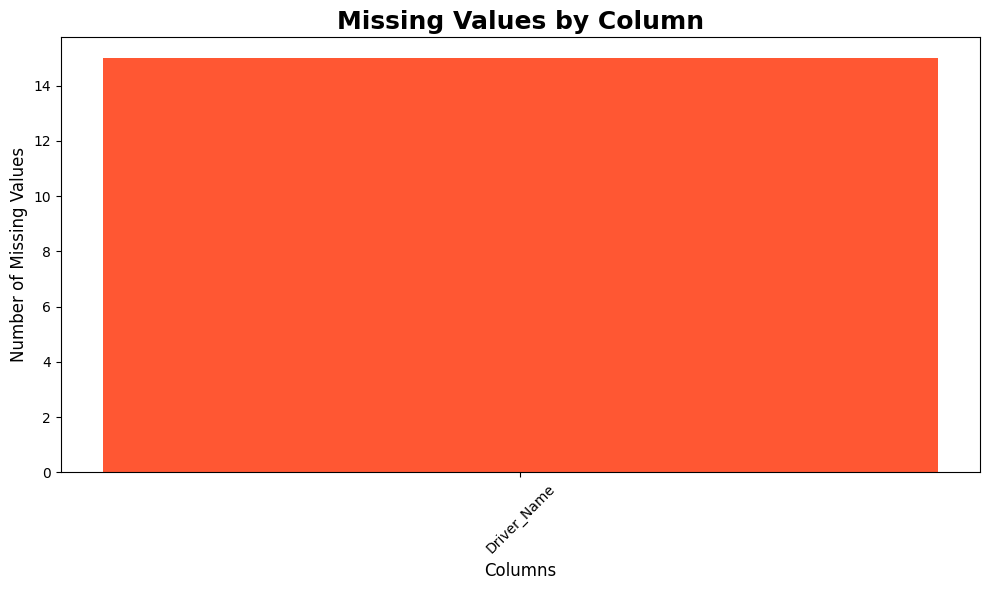

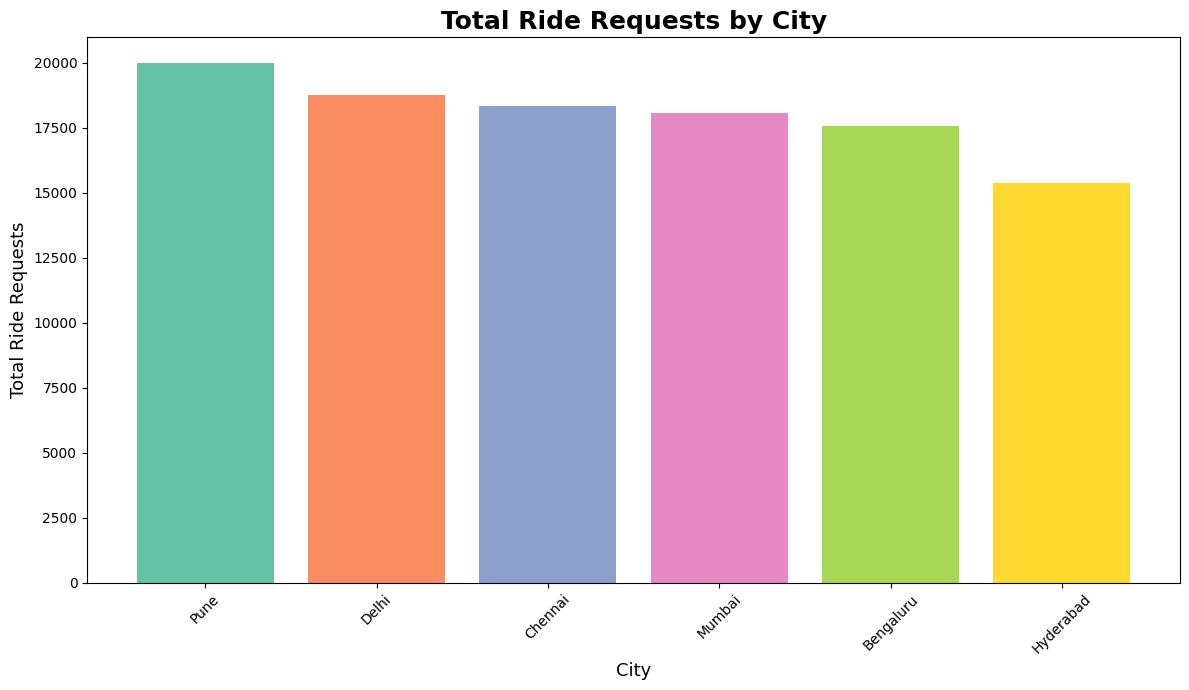

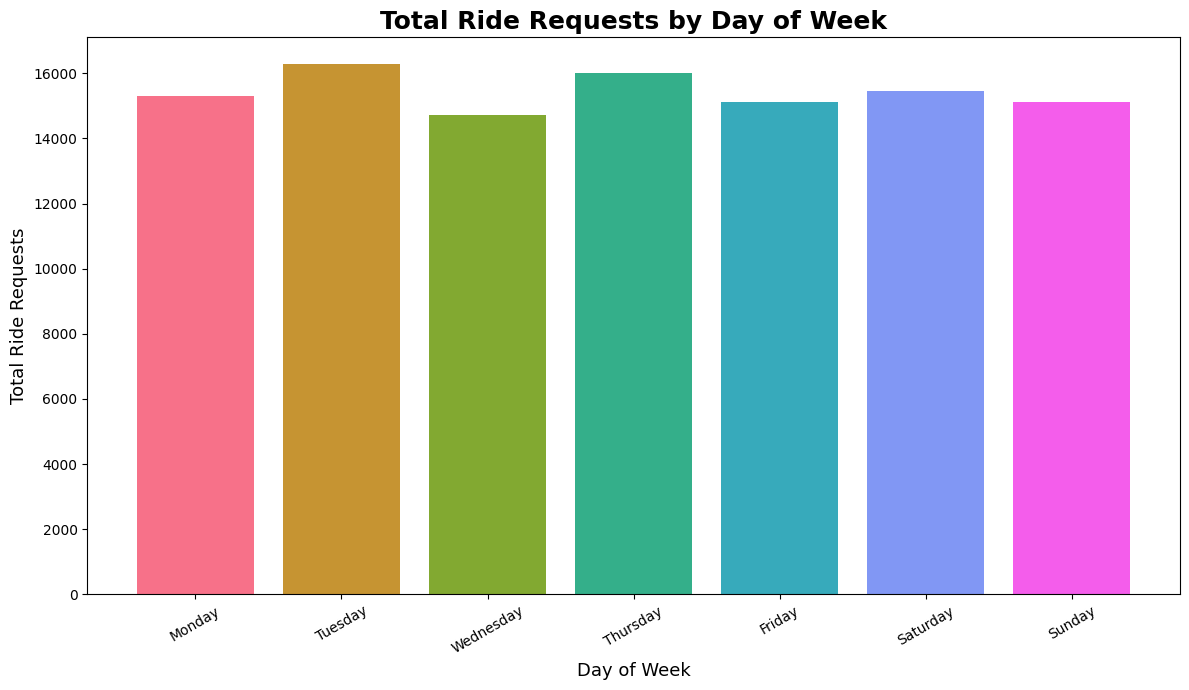

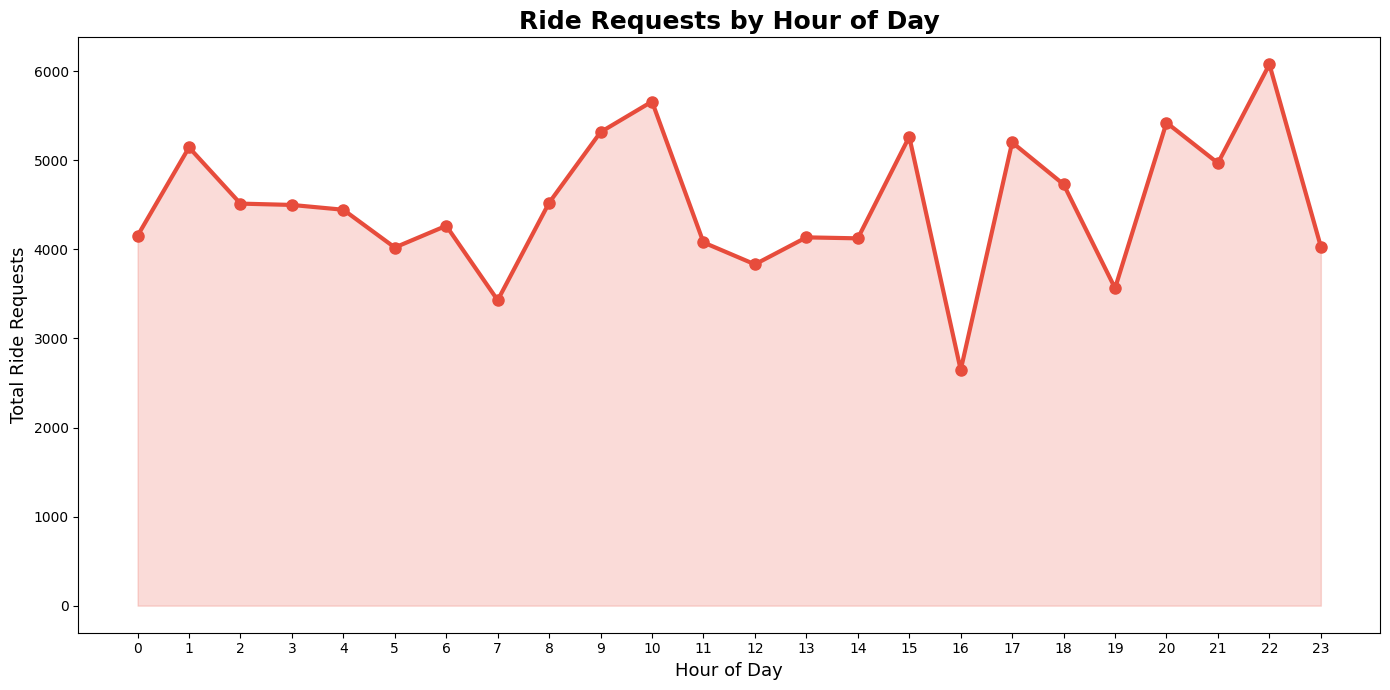

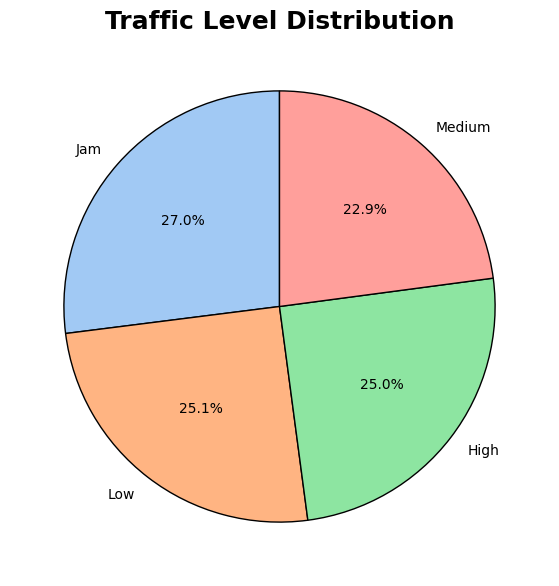

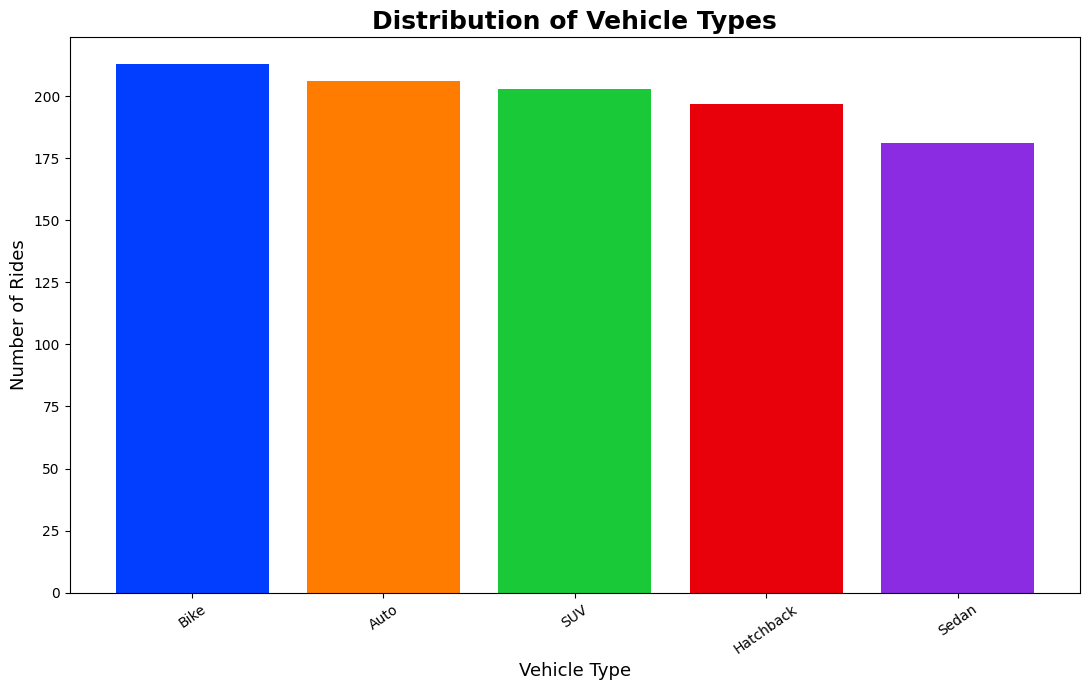

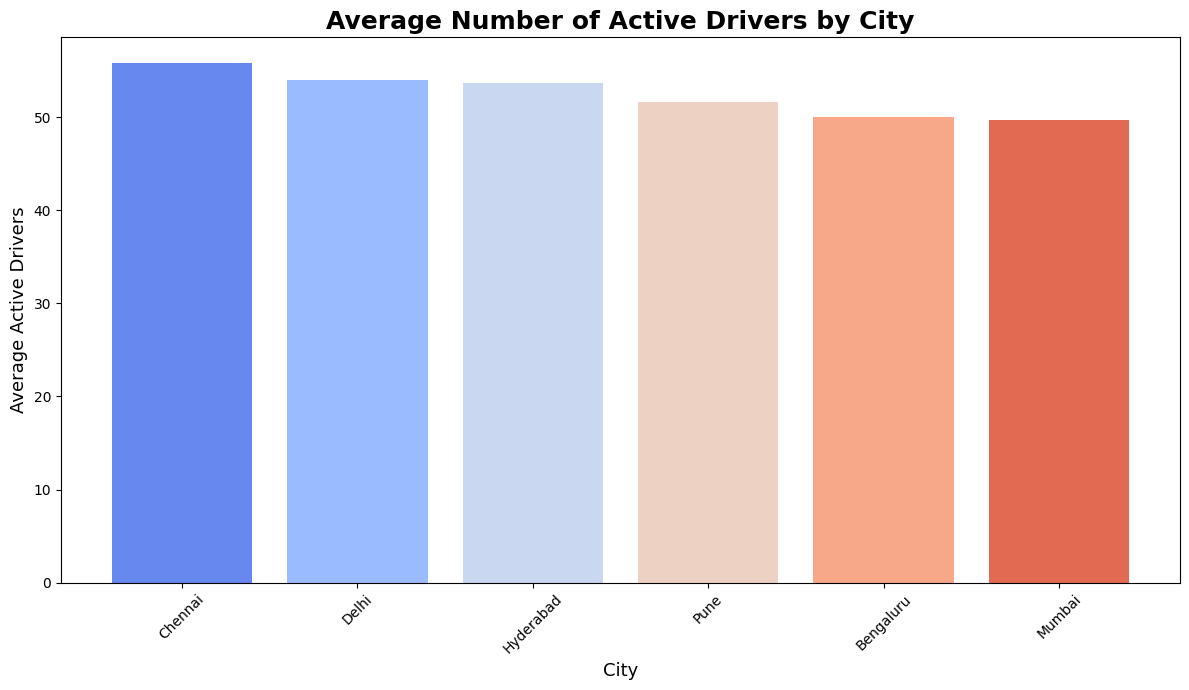

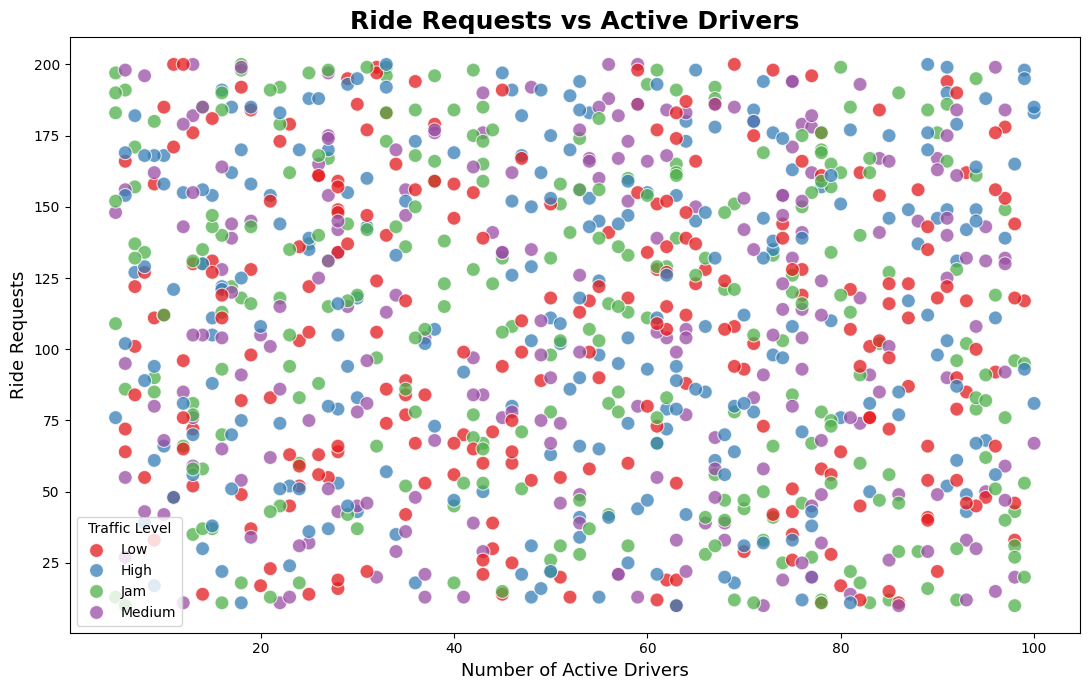

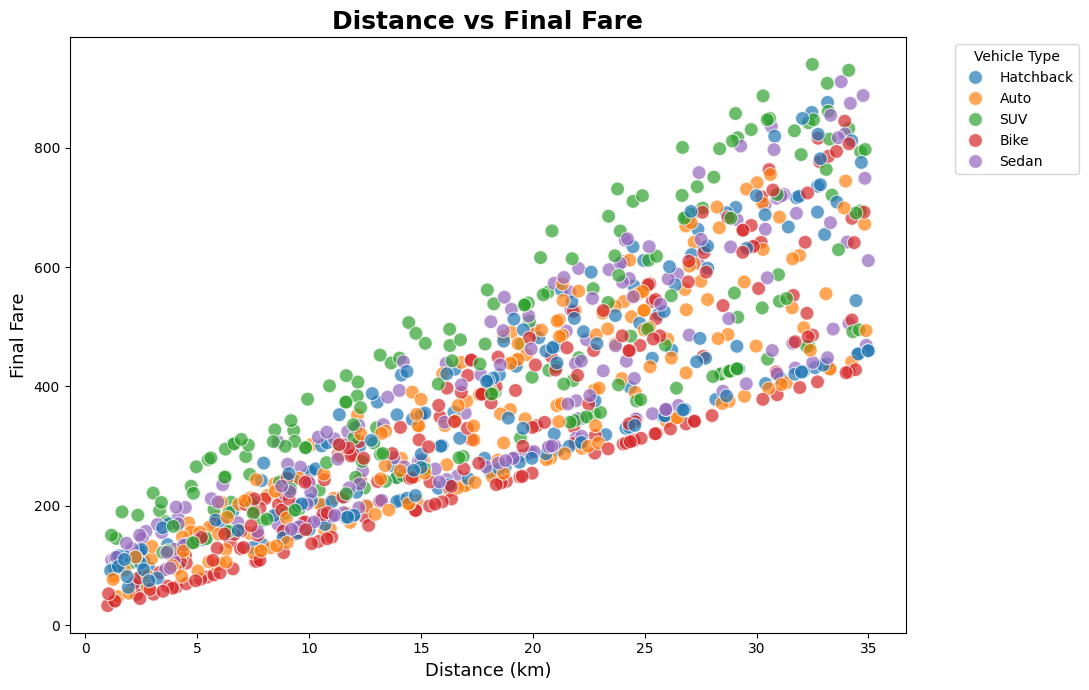

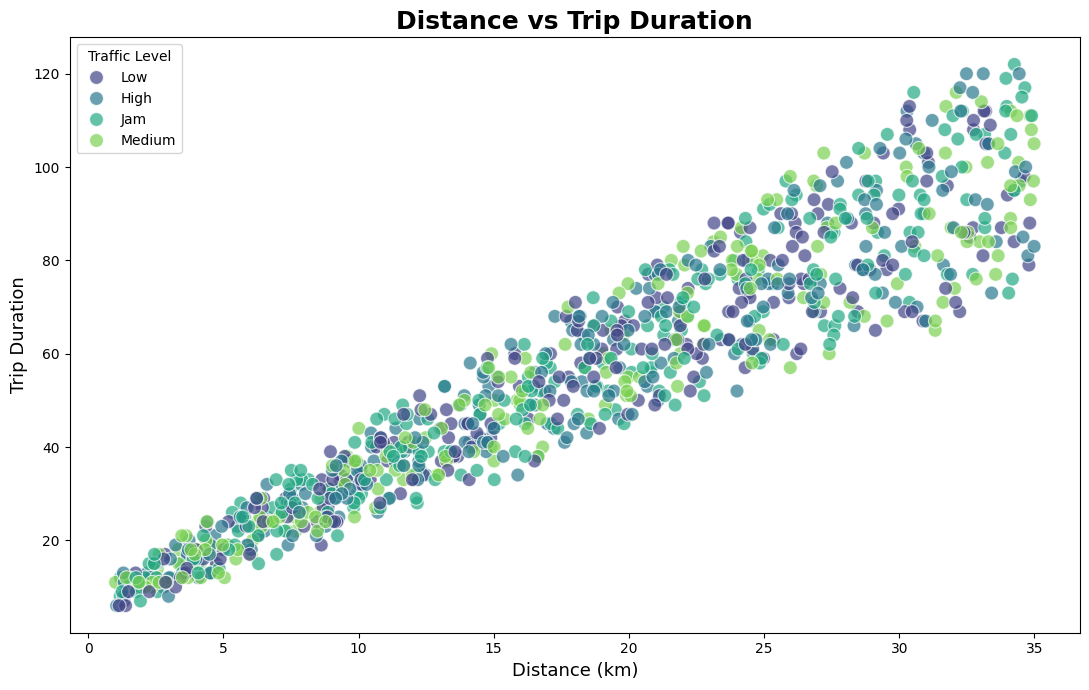

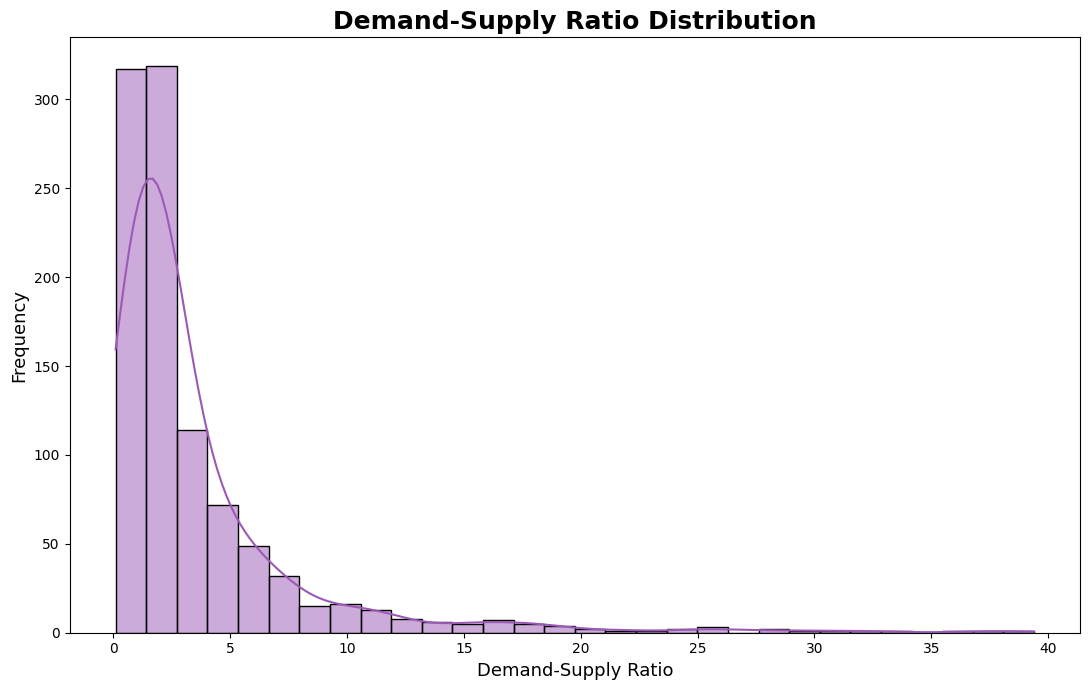

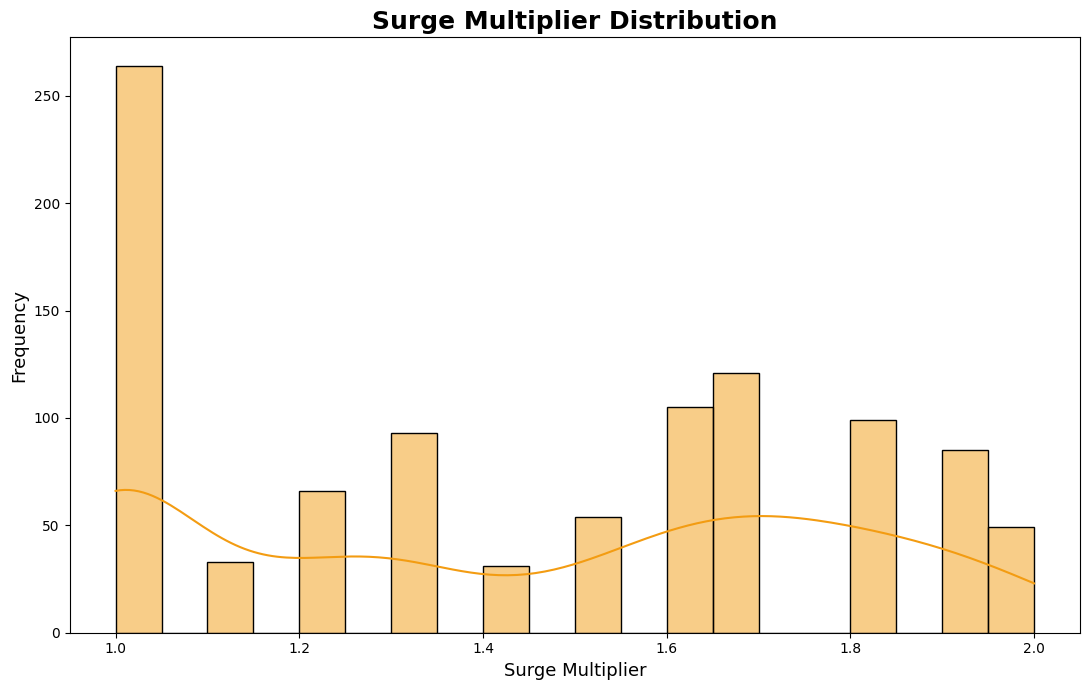

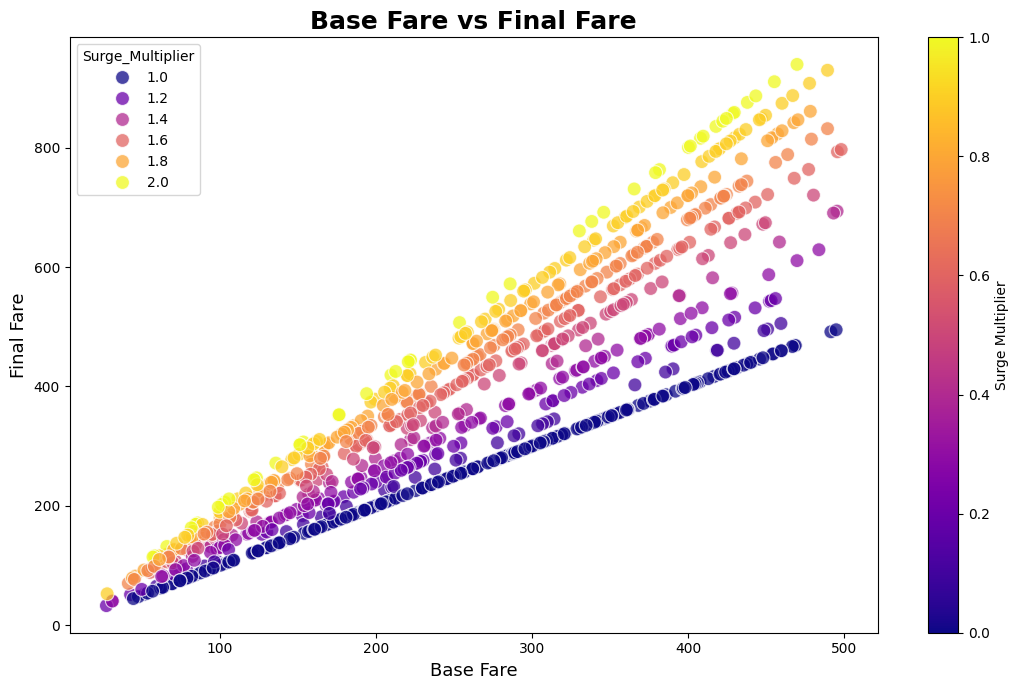

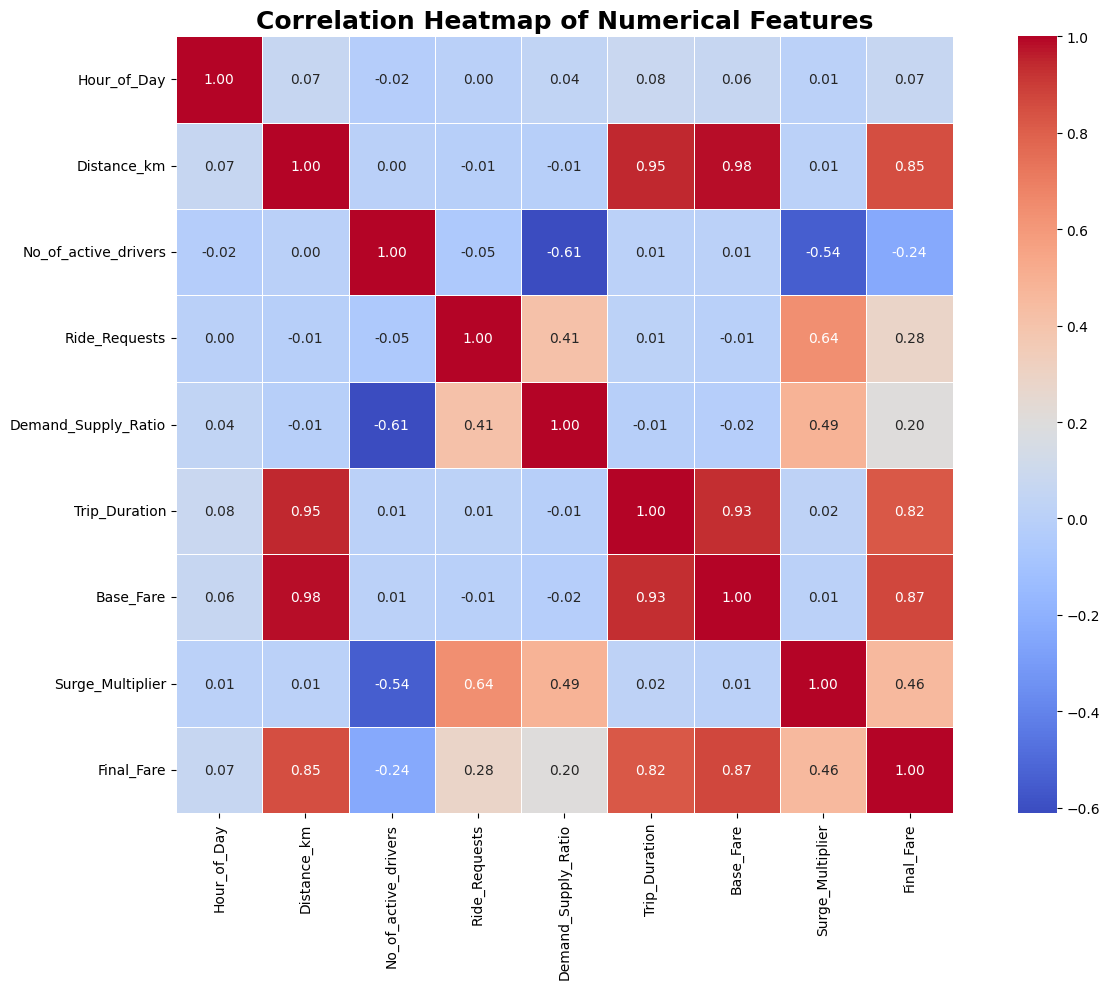

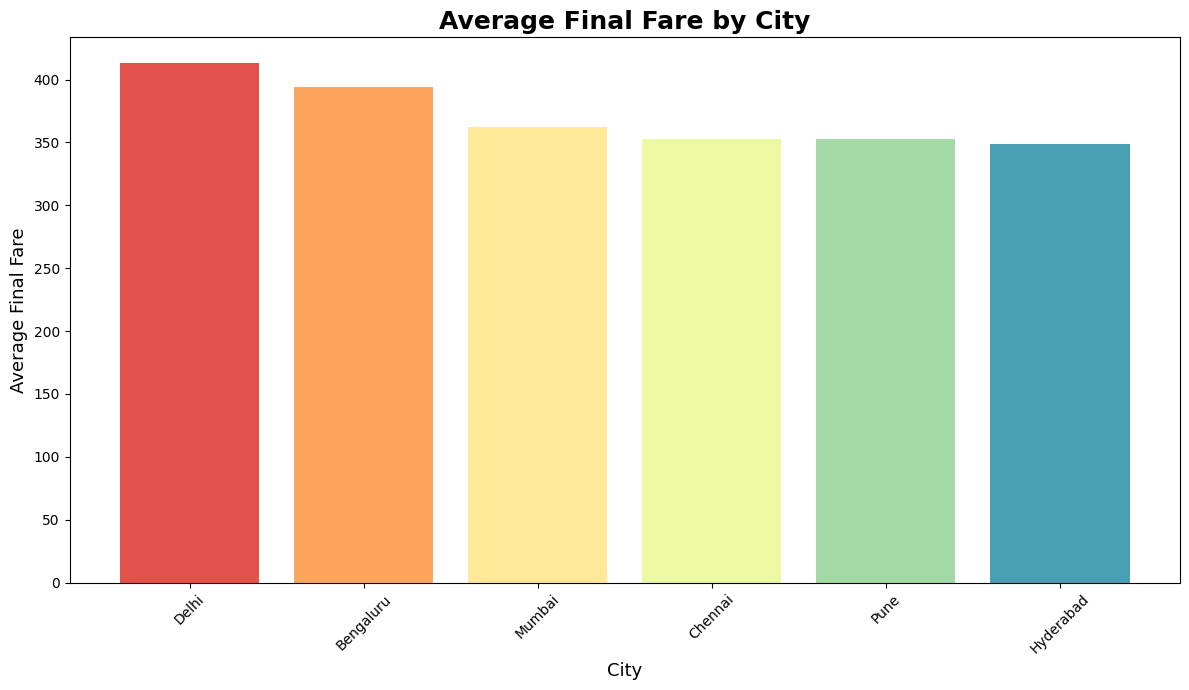

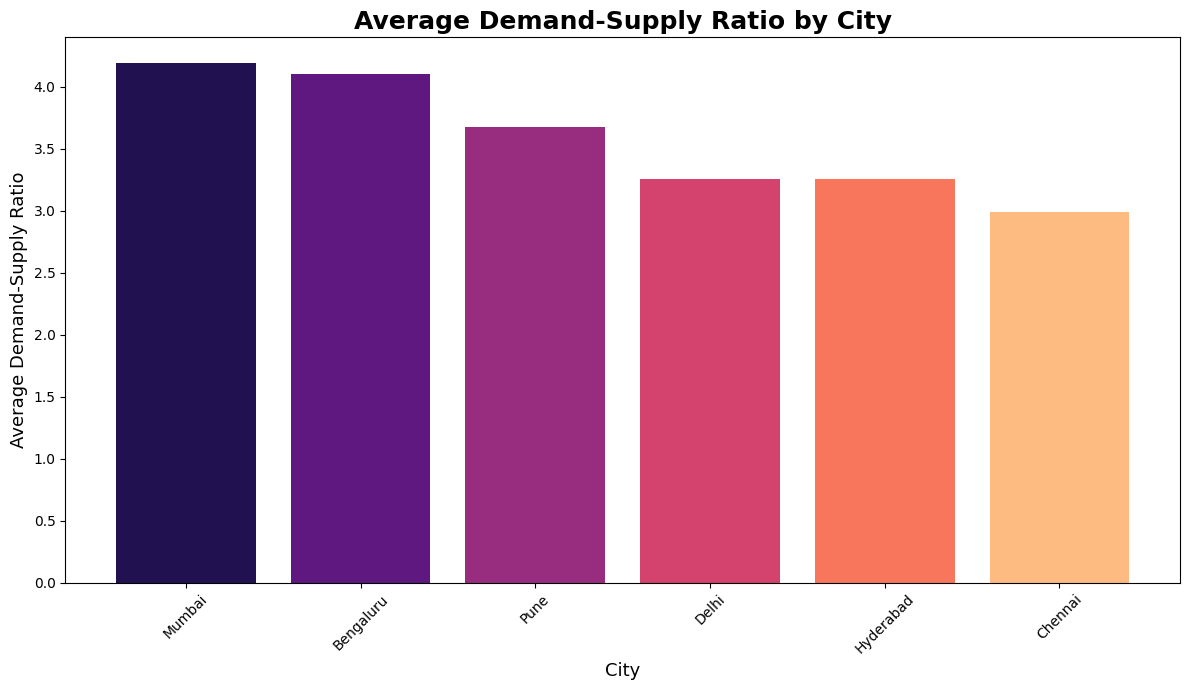

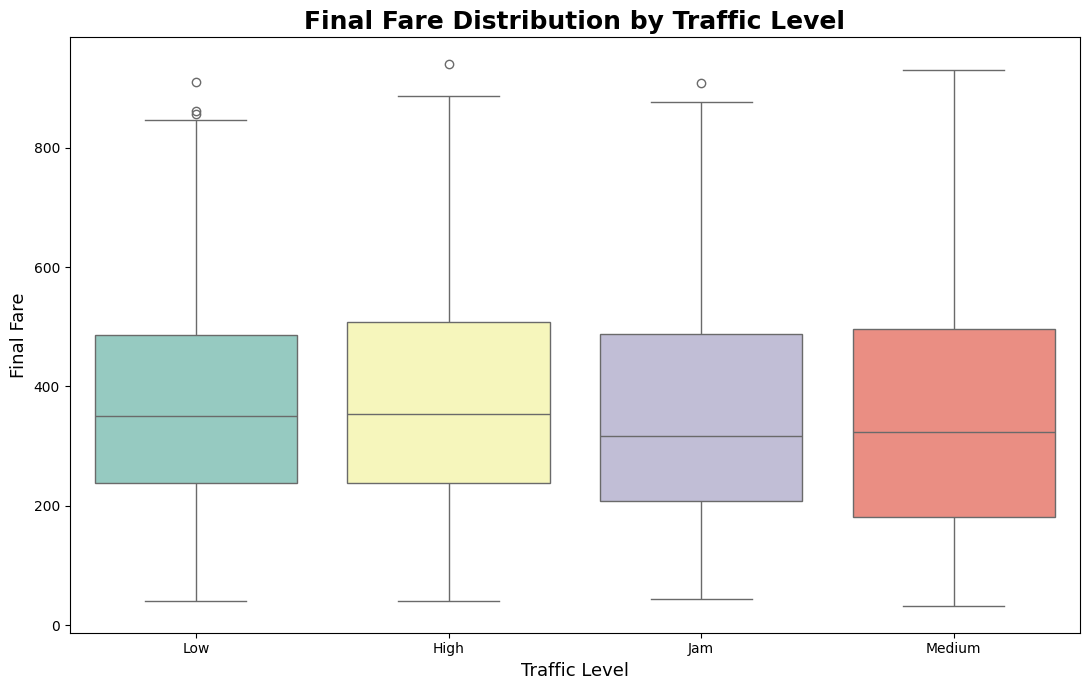

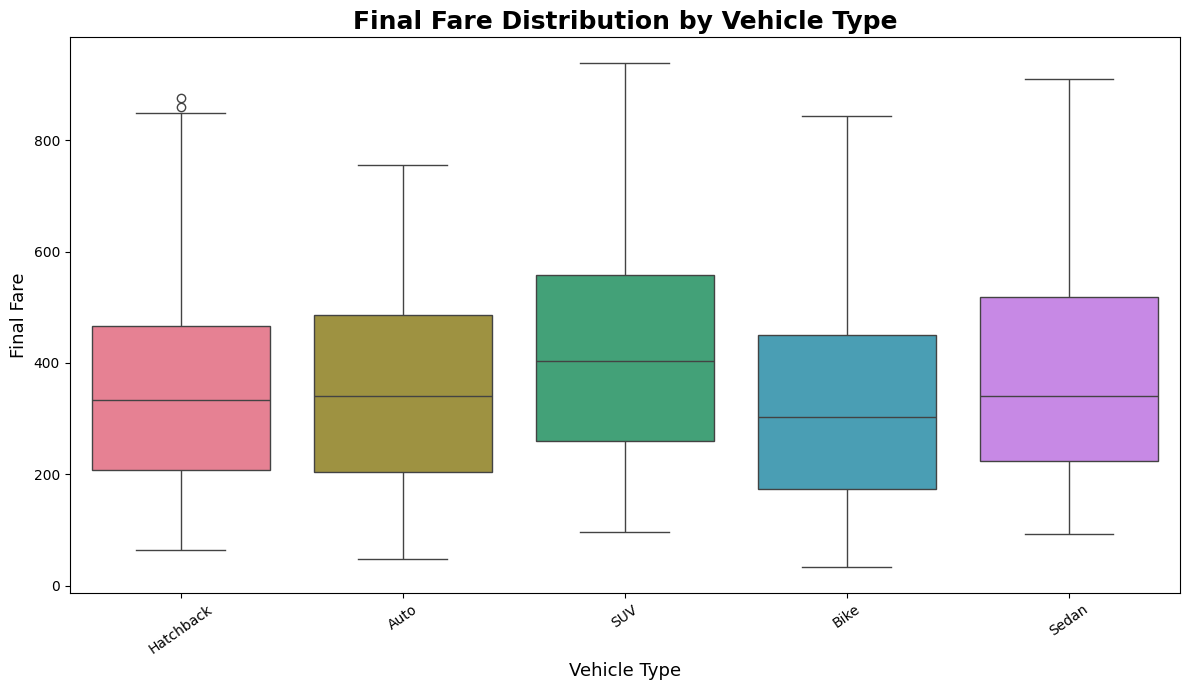

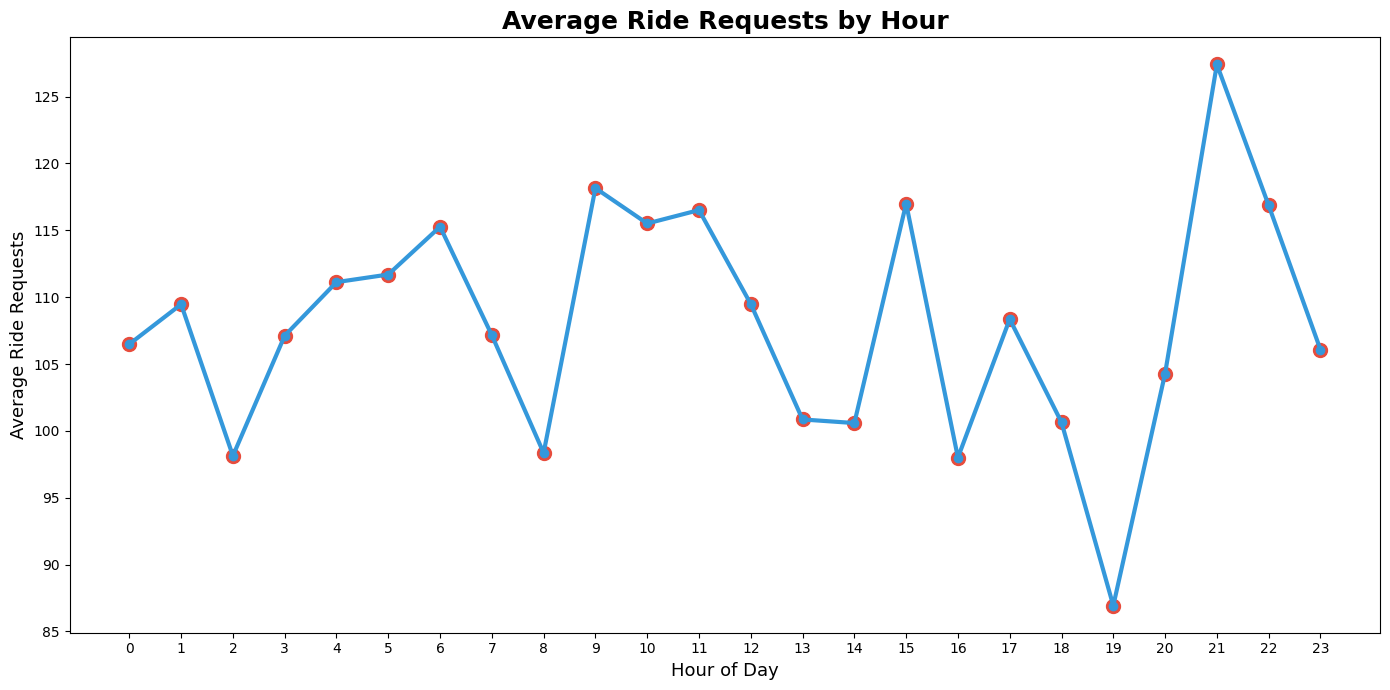

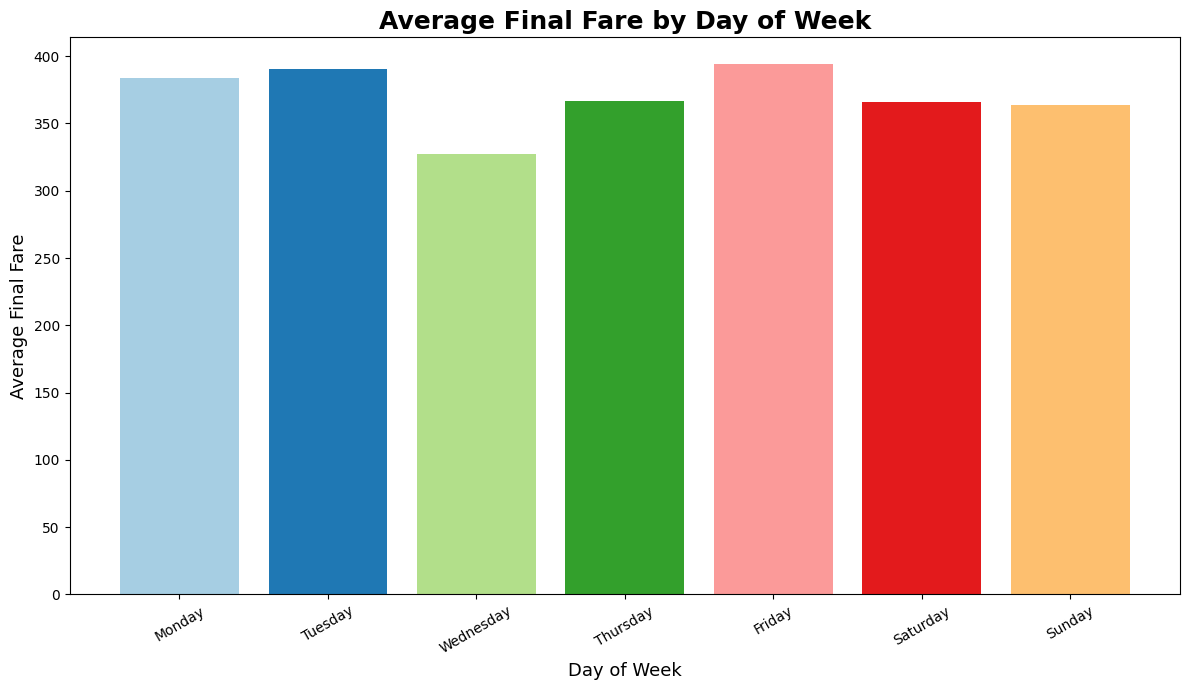

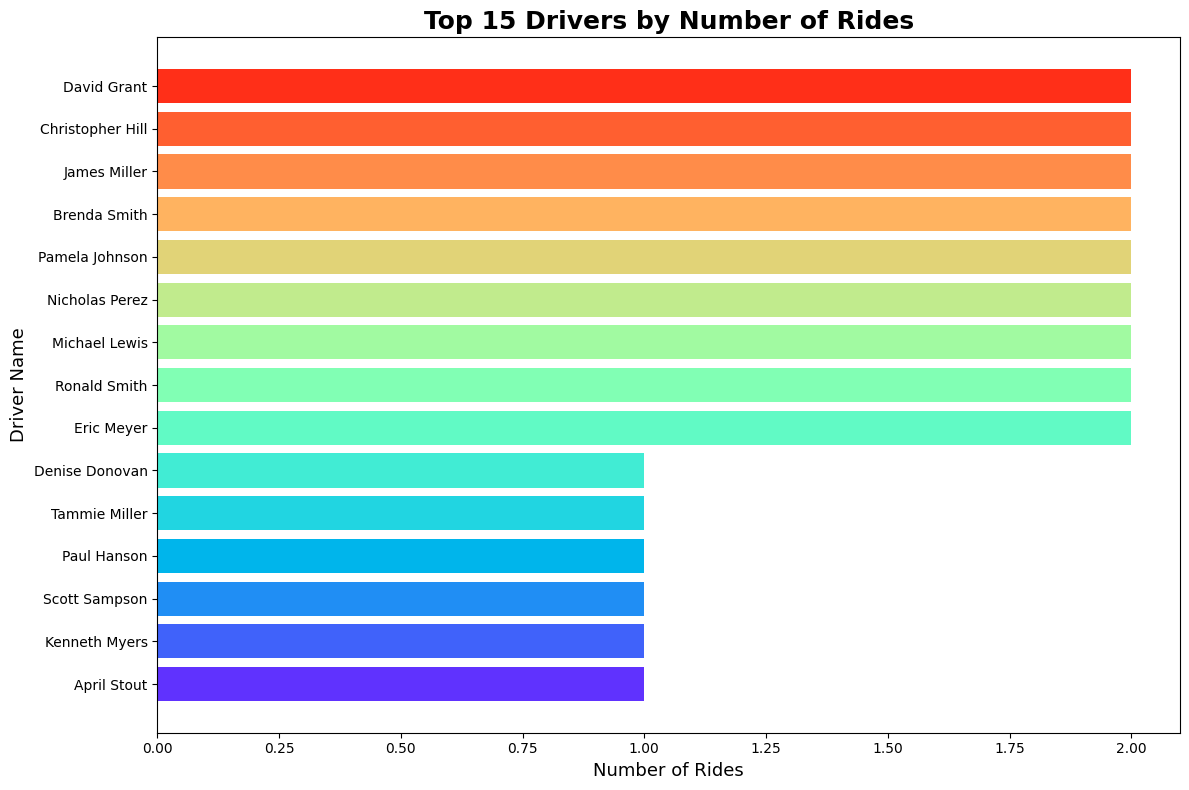

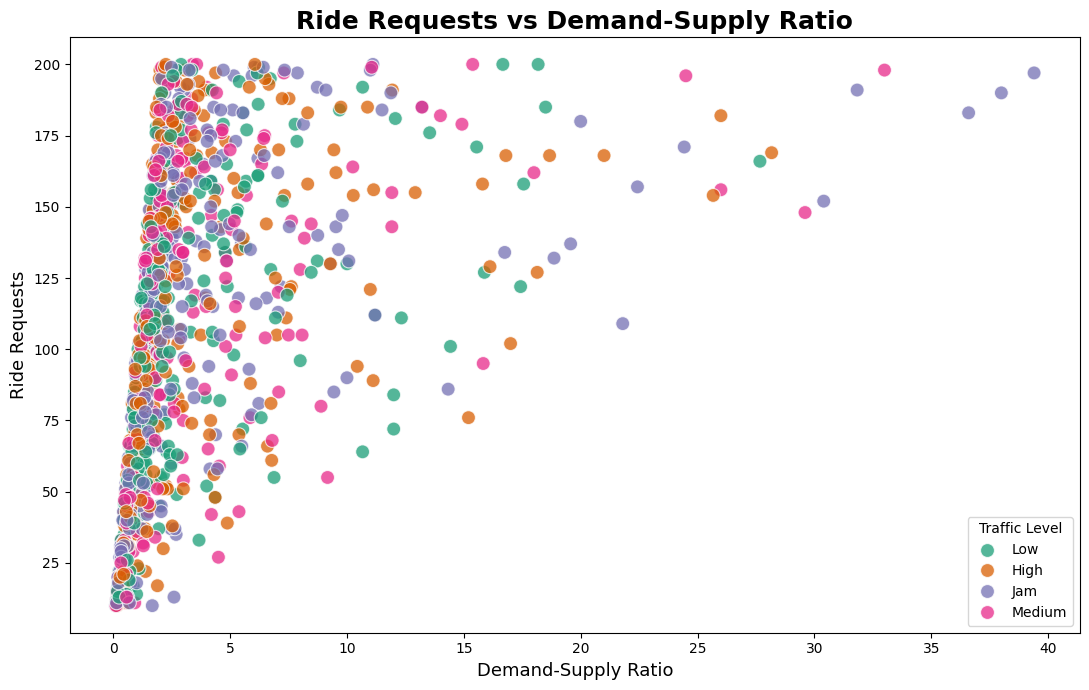

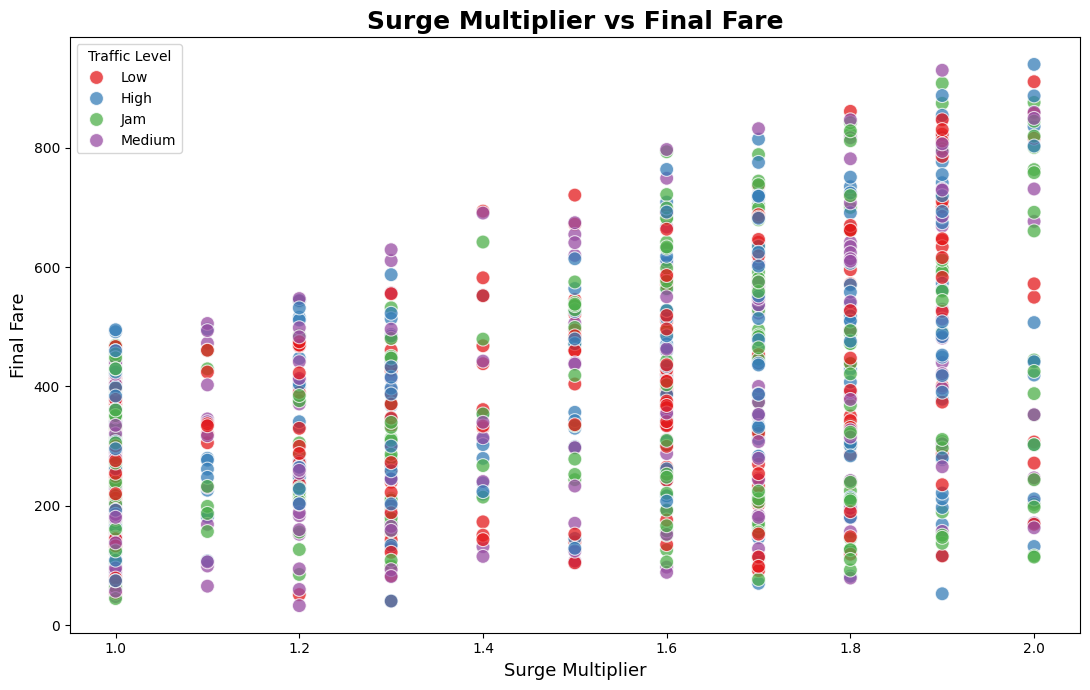

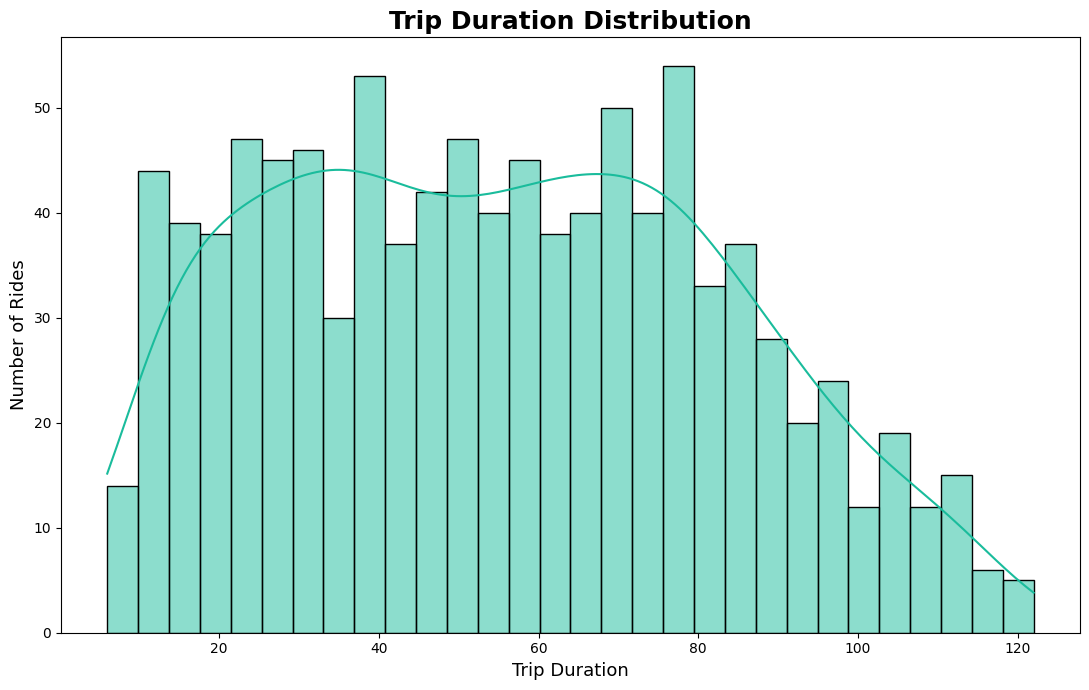

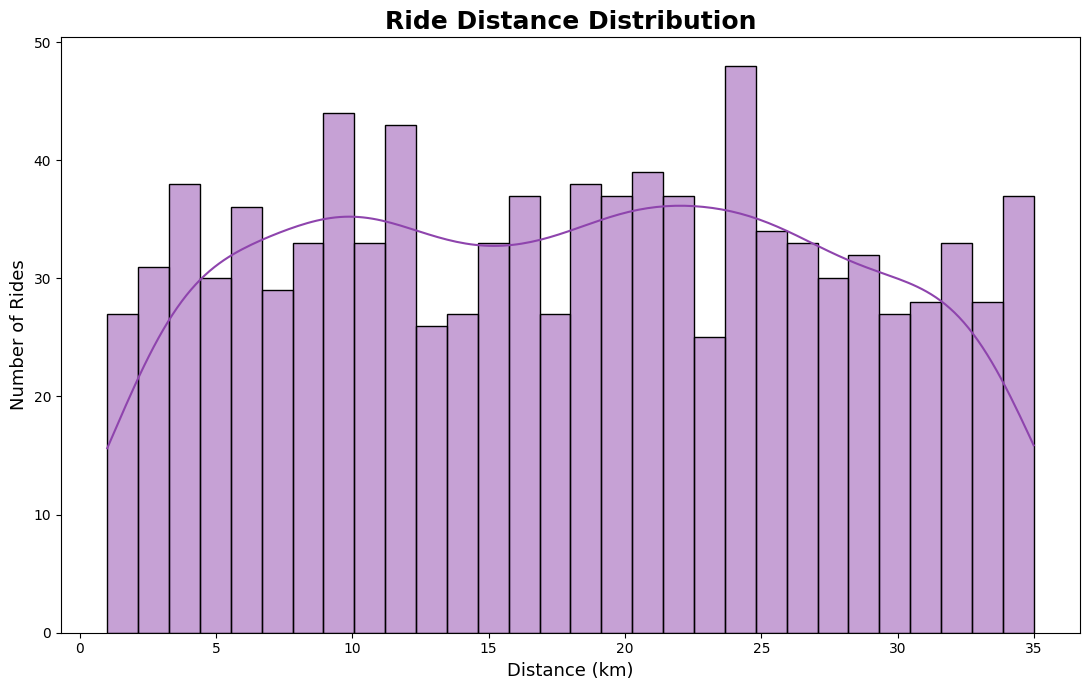

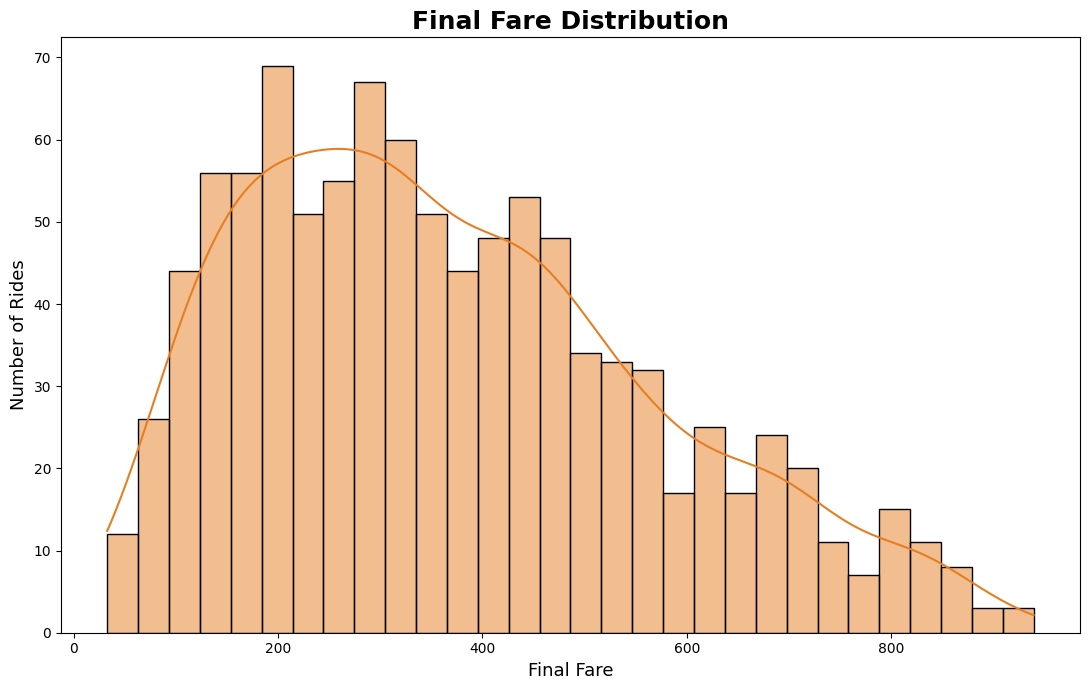

<Figure size 1400x800 with 0 Axes>

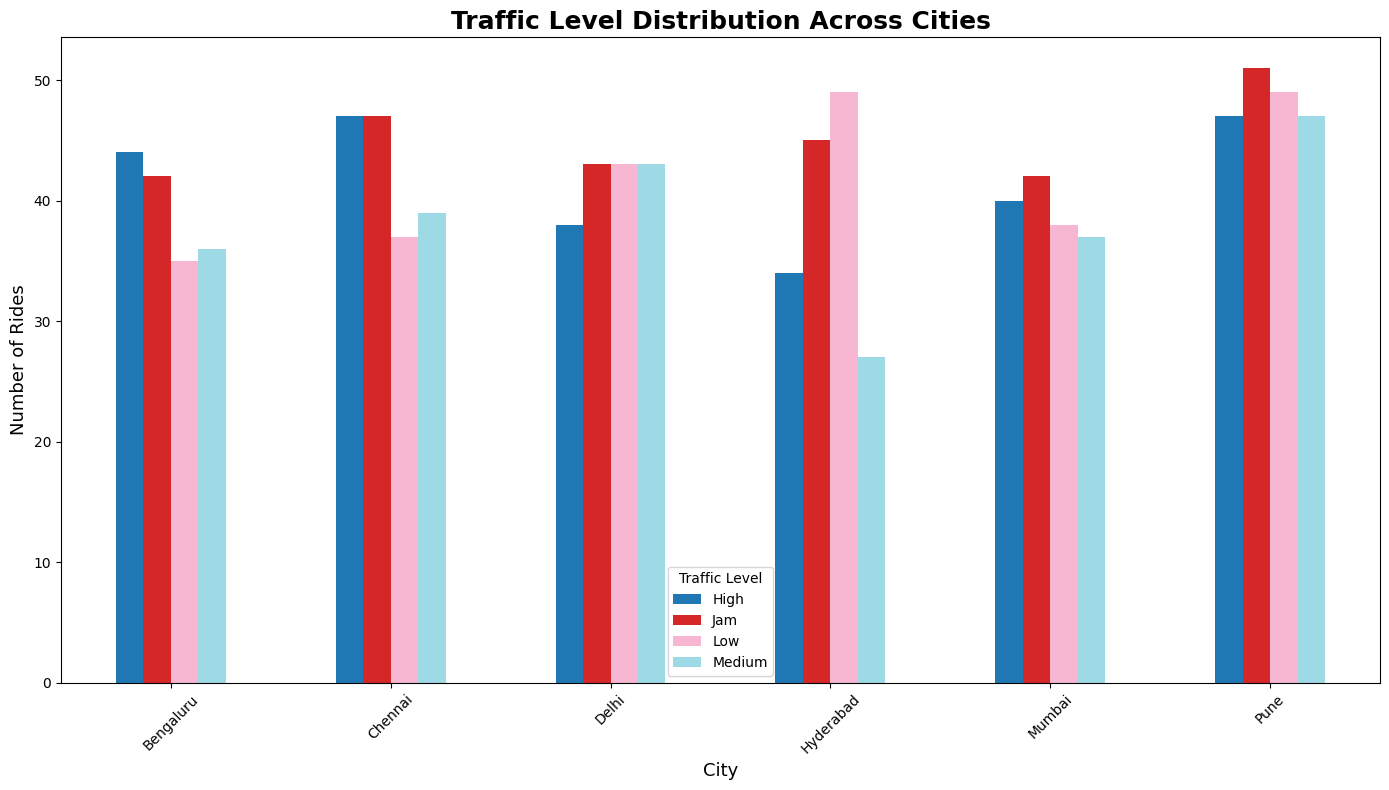

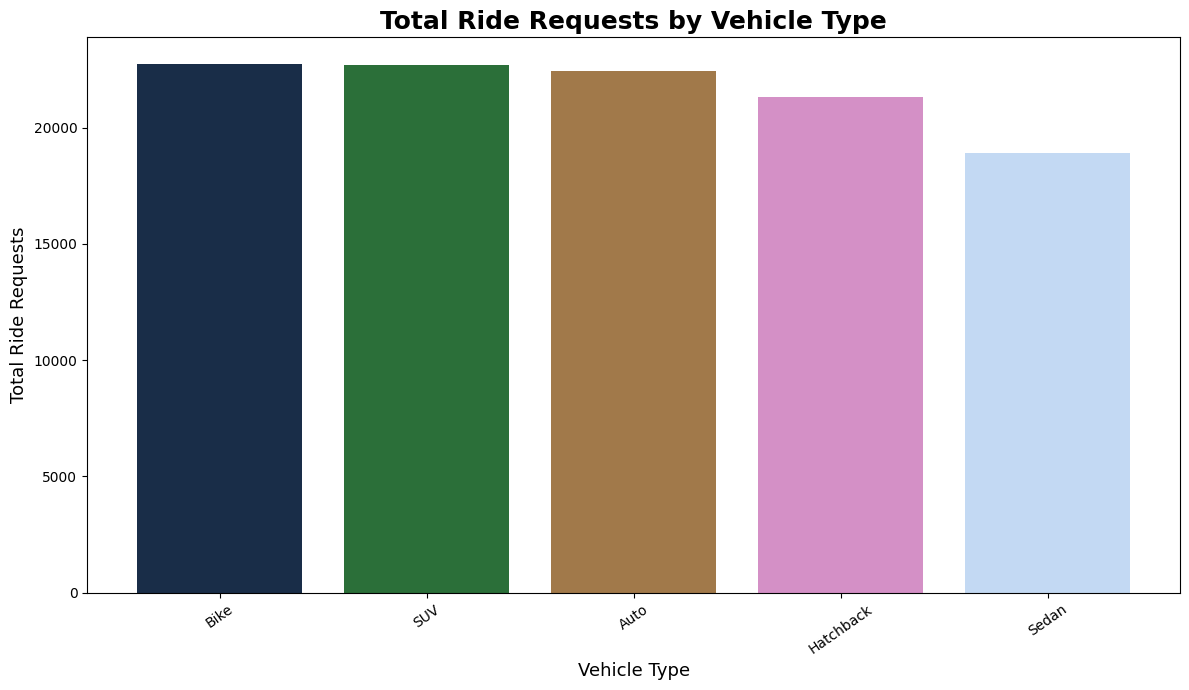

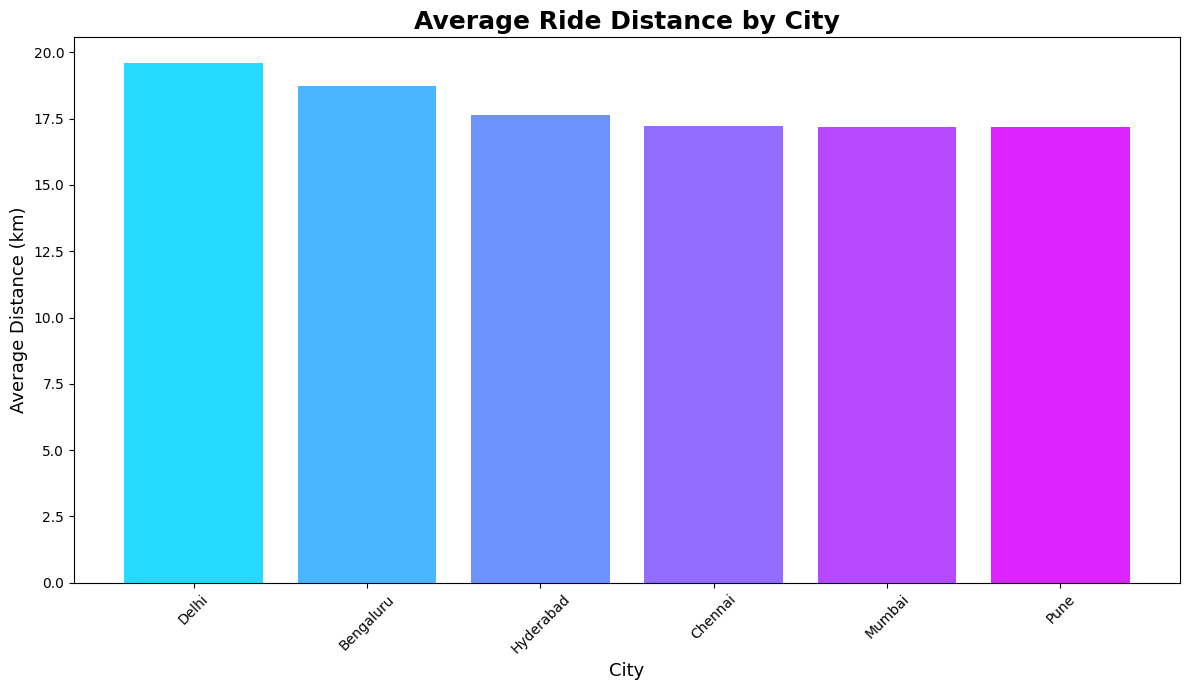

RIDE DATASET VISUALIZATION COMPLETED

Number of Records: 1000
Number of Features: 16

Unique Cities:
6

Unique Drivers:
976

Unique Vehicle Types:
5

Average Distance: 17.91
Average Ride Requests: 108.05
Average Demand-Supply Ratio: 3.57
Average Base Fare: 257.48
Average Final Fare: 370.24
Average Surge Multiplier: 1.44

Visualization completed successfully!


In [13]:
# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display columns
print("\nColumns:")
print(df.columns)

# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))

# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10, 6))

if len(missing) > 0:
    plt.bar(
        missing.index,
        missing.values,
        color=[
            "#FF5733",
            "#33C1FF",
            "#8E44AD",
            "#2ECC71",
            "#F1C40F",
            "#E74C3C"
        ][:len(missing)]
    )

    plt.title(
        "Missing Values by Column",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Columns", fontsize=12)
    plt.ylabel("Number of Missing Values", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    plt.text(
        0.5,
        0.5,
        "No Missing Values",
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    plt.title(
        "Missing Value Analysis",
        fontsize=18,
        fontweight="bold"
    )

    plt.axis("off")
    plt.show()


# ============================================================
# 5. RIDE REQUESTS BY CITY
# ============================================================

city_requests = (
    df.groupby("City")["Ride_Requests"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    city_requests.index,
    city_requests.values,
    color=sns.color_palette("Set2", len(city_requests))
)

plt.title(
    "Total Ride Requests by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City", fontsize=13)
plt.ylabel("Total Ride Requests", fontsize=13)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 6. RIDE REQUESTS BY DAY OF WEEK
# ============================================================

day_requests = (
    df.groupby("Day_of_Week")["Ride_Requests"]
    .sum()
)

# Correct weekday order if names are used
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

existing_days = [
    day for day in day_order
    if day in df["Day_of_Week"].astype(str).unique()
]

if len(existing_days) > 0:
    day_requests = day_requests.reindex(existing_days)

plt.figure(figsize=(12, 7))

plt.bar(
    day_requests.index.astype(str),
    day_requests.values,
    color=sns.color_palette("husl", len(day_requests))
)

plt.title(
    "Total Ride Requests by Day of Week",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Day of Week", fontsize=13)
plt.ylabel("Total Ride Requests", fontsize=13)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 7. RIDE REQUESTS BY HOUR
# ============================================================

hour_requests = (
    df.groupby("Hour_of_Day")["Ride_Requests"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 7))

plt.plot(
    hour_requests.index,
    hour_requests.values,
    marker="o",
    linewidth=3,
    markersize=8,
    color="#E74C3C"
)

plt.fill_between(
    hour_requests.index,
    hour_requests.values,
    alpha=0.2,
    color="#E74C3C"
)

plt.title(
    "Ride Requests by Hour of Day",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Total Ride Requests", fontsize=13)

plt.xticks(hour_requests.index)

plt.tight_layout()
plt.show()


# ============================================================
# 8. TRAFFIC LEVEL DISTRIBUTION
# ============================================================

traffic_counts = df["Traffic_Level"].value_counts()

plt.figure(figsize=(9, 7))

plt.pie(
    traffic_counts.values,
    labels=traffic_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel", len(traffic_counts)),
    wedgeprops={"edgecolor": "black"}
)

plt.title(
    "Traffic Level Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()


# ============================================================
# 9. VEHICLE TYPE DISTRIBUTION
# ============================================================

vehicle_counts = df["Type_of_vehicle"].value_counts()

plt.figure(figsize=(11, 7))

plt.bar(
    vehicle_counts.index.astype(str),
    vehicle_counts.values,
    color=sns.color_palette("bright", len(vehicle_counts))
)

plt.title(
    "Distribution of Vehicle Types",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Vehicle Type", fontsize=13)
plt.ylabel("Number of Rides", fontsize=13)

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()


# ============================================================
# 10. ACTIVE DRIVERS BY CITY
# ============================================================

active_drivers = (
    df.groupby("City")["No_of_active_drivers"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    active_drivers.index,
    active_drivers.values,
    color=sns.color_palette("coolwarm", len(active_drivers))
)

plt.title(
    "Average Number of Active Drivers by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City", fontsize=13)
plt.ylabel("Average Active Drivers", fontsize=13)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 11. RIDE REQUESTS VS ACTIVE DRIVERS
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="No_of_active_drivers",
    y="Ride_Requests",
    hue="Traffic_Level",
    palette="Set1",
    s=100,
    alpha=0.75
)

plt.title(
    "Ride Requests vs Active Drivers",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Active Drivers", fontsize=13)
plt.ylabel("Ride Requests", fontsize=13)

plt.legend(title="Traffic Level")

plt.tight_layout()
plt.show()


# ============================================================
# 12. DISTANCE VS FINAL FARE
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Final_Fare",
    hue="Type_of_vehicle",
    palette="tab10",
    s=100,
    alpha=0.7
)

plt.title(
    "Distance vs Final Fare",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Distance (km)", fontsize=13)
plt.ylabel("Final Fare", fontsize=13)

plt.legend(
    title="Vehicle Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. DISTANCE VS TRIP DURATION
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Trip_Duration",
    hue="Traffic_Level",
    palette="viridis",
    s=100,
    alpha=0.7
)

plt.title(
    "Distance vs Trip Duration",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Distance (km)", fontsize=13)
plt.ylabel("Trip Duration", fontsize=13)

plt.legend(title="Traffic Level")

plt.tight_layout()
plt.show()


# ============================================================
# 14. DEMAND SUPPLY RATIO DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 7))

sns.histplot(
    data=df,
    x="Demand_Supply_Ratio",
    bins=30,
    kde=True,
    color="#9B59B6"
)

plt.title(
    "Demand-Supply Ratio Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Demand-Supply Ratio", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 15. SURGE MULTIPLIER DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 7))

sns.histplot(
    data=df,
    x="Surge_Multiplier",
    bins=20,
    kde=True,
    color="#F39C12"
)

plt.title(
    "Surge Multiplier Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Surge Multiplier", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 16. BASE FARE VS FINAL FARE
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Base_Fare",
    y="Final_Fare",
    hue="Surge_Multiplier",
    palette="plasma",
    s=100,
    alpha=0.75
)

plt.title(
    "Base Fare vs Final Fare",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Base Fare", fontsize=13)
plt.ylabel("Final Fare", fontsize=13)

plt.colorbar(
    plt.cm.ScalarMappable(
        cmap="plasma"
    ),
    ax=plt.gca(),
    label="Surge Multiplier"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Hour_of_Day",
    "Distance_km",
    "No_of_active_drivers",
    "Ride_Requests",
    "Demand_Supply_Ratio",
    "Trip_Duration",
    "Base_Fare",
    "Surge_Multiplier",
    "Final_Fare"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. CITY-WISE AVERAGE FINAL FARE
# ============================================================

city_fare = (
    df.groupby("City")["Final_Fare"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    city_fare.index,
    city_fare.values,
    color=sns.color_palette("Spectral", len(city_fare))
)

plt.title(
    "Average Final Fare by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City", fontsize=13)
plt.ylabel("Average Final Fare", fontsize=13)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 19. CITY-WISE DEMAND-SUPPLY RATIO
# ============================================================

city_ratio = (
    df.groupby("City")["Demand_Supply_Ratio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    city_ratio.index,
    city_ratio.values,
    color=sns.color_palette("magma", len(city_ratio))
)

plt.title(
    "Average Demand-Supply Ratio by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City", fontsize=13)
plt.ylabel("Average Demand-Supply Ratio", fontsize=13)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 20. TRAFFIC LEVEL VS FINAL FARE
# ============================================================

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df,
    x="Traffic_Level",
    y="Final_Fare",
    hue="Traffic_Level",
    palette="Set3",
    legend=False
)

plt.title(
    "Final Fare Distribution by Traffic Level",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Traffic Level", fontsize=13)
plt.ylabel("Final Fare", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 21. VEHICLE TYPE VS FINAL FARE
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="Type_of_vehicle",
    y="Final_Fare",
    hue="Type_of_vehicle",
    palette="husl",
    legend=False
)

plt.title(
    "Final Fare Distribution by Vehicle Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Vehicle Type", fontsize=13)
plt.ylabel("Final Fare", fontsize=13)

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()


# ============================================================
# 22. HOURLY AVERAGE RIDE REQUESTS
# ============================================================

hour_avg = (
    df.groupby("Hour_of_Day")["Ride_Requests"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(14, 7))

plt.plot(
    hour_avg.index,
    hour_avg.values,
    marker="o",
    linewidth=3,
    color="#3498DB"
)

plt.scatter(
    hour_avg.index,
    hour_avg.values,
    s=100,
    color="#E74C3C"
)

plt.title(
    "Average Ride Requests by Hour",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Average Ride Requests", fontsize=13)

plt.xticks(hour_avg.index)

plt.tight_layout()
plt.show()


# ============================================================
# 23. DAY-WISE AVERAGE FINAL FARE
# ============================================================

day_fare = (
    df.groupby("Day_of_Week")["Final_Fare"]
    .mean()
)

if len(existing_days) > 0:
    day_fare = day_fare.reindex(existing_days)

plt.figure(figsize=(12, 7))

plt.bar(
    day_fare.index.astype(str),
    day_fare.values,
    color=sns.color_palette("Paired", len(day_fare))
)

plt.title(
    "Average Final Fare by Day of Week",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Day of Week", fontsize=13)
plt.ylabel("Average Final Fare", fontsize=13)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 24. TOP 15 DRIVERS BY NUMBER OF RIDES
# ============================================================

top_drivers = (
    df["Driver_Name"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_drivers.index,
    top_drivers.values,
    color=sns.color_palette("rainbow", len(top_drivers))
)

plt.title(
    "Top 15 Drivers by Number of Rides",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Rides", fontsize=13)
plt.ylabel("Driver Name", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 25. RIDE REQUESTS VS DEMAND-SUPPLY RATIO
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Demand_Supply_Ratio",
    y="Ride_Requests",
    hue="Traffic_Level",
    palette="Dark2",
    s=100,
    alpha=0.75
)

plt.title(
    "Ride Requests vs Demand-Supply Ratio",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Demand-Supply Ratio", fontsize=13)
plt.ylabel("Ride Requests", fontsize=13)

plt.legend(title="Traffic Level")

plt.tight_layout()
plt.show()


# ============================================================
# 26. SURGE MULTIPLIER VS FINAL FARE
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Surge_Multiplier",
    y="Final_Fare",
    hue="Traffic_Level",
    palette="Set1",
    s=100,
    alpha=0.75
)

plt.title(
    "Surge Multiplier vs Final Fare",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Surge Multiplier", fontsize=13)
plt.ylabel("Final Fare", fontsize=13)

plt.legend(title="Traffic Level")

plt.tight_layout()
plt.show()


# ============================================================
# 27. TRIP DURATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 7))

sns.histplot(
    data=df,
    x="Trip_Duration",
    bins=30,
    kde=True,
    color="#1ABC9C"
)

plt.title(
    "Trip Duration Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Trip Duration", fontsize=13)
plt.ylabel("Number of Rides", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 28. DISTANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 7))

sns.histplot(
    data=df,
    x="Distance_km",
    bins=30,
    kde=True,
    color="#8E44AD"
)

plt.title(
    "Ride Distance Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Distance (km)", fontsize=13)
plt.ylabel("Number of Rides", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 29. FINAL FARE DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 7))

sns.histplot(
    data=df,
    x="Final_Fare",
    bins=30,
    kde=True,
    color="#E67E22"
)

plt.title(
    "Final Fare Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Final Fare", fontsize=13)
plt.ylabel("Number of Rides", fontsize=13)

plt.tight_layout()
plt.show()


# ============================================================
# 30. CITY VS TRAFFIC LEVEL
# ============================================================

city_traffic = pd.crosstab(
    df["City"],
    df["Traffic_Level"]
)

plt.figure(figsize=(14, 8))

city_traffic.plot(
    kind="bar",
    figsize=(14, 8),
    colormap="tab20"
)

plt.title(
    "Traffic Level Distribution Across Cities",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City", fontsize=13)
plt.ylabel("Number of Rides", fontsize=13)

plt.xticks(rotation=45)

plt.legend(title="Traffic Level")

plt.tight_layout()
plt.show()


# ============================================================
# 31. VEHICLE TYPE VS RIDE REQUESTS
# ============================================================

vehicle_requests = (
    df.groupby("Type_of_vehicle")["Ride_Requests"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    vehicle_requests.index,
    vehicle_requests.values,
    color=sns.color_palette("cubehelix", len(vehicle_requests))
)

plt.title(
    "Total Ride Requests by Vehicle Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Vehicle Type", fontsize=13)
plt.ylabel("Total Ride Requests", fontsize=13)

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()


# ============================================================
# 32. CITY VS AVERAGE DISTANCE
# ============================================================

city_distance = (
    df.groupby("City")["Distance_km"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

plt.bar(
    city_distance.index,
    city_distance.values,
    color=sns.color_palette("cool", len(city_distance))
)

plt.title(
    "Average Ride Distance by City",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("City", fontsize=13)
plt.ylabel("Average Distance (km)", fontsize=13)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("=" * 70)
print("RIDE DATASET VISUALIZATION COMPLETED")
print("=" * 70)

print("\nNumber of Records:", len(df))
print("Number of Features:", len(df.columns))

print("\nUnique Cities:")
print(df["City"].nunique())

print("\nUnique Drivers:")
print(df["Driver_Name"].nunique())

print("\nUnique Vehicle Types:")
print(df["Type_of_vehicle"].nunique())

print("\nAverage Distance:", round(df["Distance_km"].mean(), 2))

print("Average Ride Requests:", round(df["Ride_Requests"].mean(), 2))

print("Average Demand-Supply Ratio:",
      round(df["Demand_Supply_Ratio"].mean(), 2))

print("Average Base Fare:",
      round(df["Base_Fare"].mean(), 2))

print("Average Final Fare:",
      round(df["Final_Fare"].mean(), 2))

print("Average Surge Multiplier:",
      round(df["Surge_Multiplier"].mean(), 2))

print("\nVisualization completed successfully!")

## Feature engineering

DATASET LOADED

Shape of Dataset:
(1000, 16)

Columns:
['User_ID', 'Driver_Name', 'City', 'Ride_Date', 'Hour_of_Day', 'Day_of_Week', 'Distance_km', 'Traffic_Level', 'Type_of_vehicle', 'No_of_active_drivers', 'Ride_Requests', 'Demand_Supply_Ratio', 'Trip_Duration', 'Base_Fare', 'Surge_Multiplier', 'Final_Fare']

First 5 Rows:


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
0,USER-21819-Bcbf,Patrick Sanchez,Pune,05-11-2025,0,Friday,26.21,Low,Hatchback,36,67,1.86,60,354.52,1.3,460.88
1,USER-79402-SBvr,Meredith Barnes,Mumbai,13-10-2025,2,Friday,21.08,High,Auto,9,17,1.89,50,282.96,1.3,367.85
2,USER-40781-yfJs,Ian Cooper,Bengaluru,16-06-2026,6,Sunday,25.34,High,Hatchback,94,149,1.59,75,344.08,1.3,447.30
3,USER-41316-rDOx,Amber Perez,Mumbai,15-10-2025,0,Monday,26.80,High,Auto,25,188,7.52,76,351.60,1.6,562.56
4,USER-76483-RuXX,Kimberly Sanchez,Chennai,06-09-2025,10,Friday,4.48,High,SUV,53,34,0.64,18,133.76,1.0,133.76



Target Variable: Final_Fare

Target Statistics:


count    1000.000000
mean      370.238310
std       199.232597
min        32.540000
25%       208.205000
50%       338.580000
75%       493.767500
max       939.760000
Name: Final_Fare, dtype: float64


Shape after removing duplicates:
(1000, 16)

Date processing completed.

Removed columns:
['User_ID', 'Driver_Name']

Feature Shape:
(1000, 16)

Target Shape:
(1000,)

Categorical Columns:
['City', 'Day_of_Week', 'Traffic_Level', 'Type_of_vehicle']

Numerical Columns:
['Hour_of_Day', 'Distance_km', 'No_of_active_drivers', 'Ride_Requests', 'Demand_Supply_Ratio', 'Trip_Duration', 'Base_Fare', 'Surge_Multiplier', 'Ride_Year', 'Ride_Month', 'Ride_Day', 'Ride_DayOfYear']

TRAIN-TEST SPLIT
Training samples: 800
Testing samples : 200

LABEL ENCODING

Column: City
Classes:
['Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Mumbai', 'Pune']

Column: Day_of_Week
Classes:
['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']

Column: Traffic_Level
Classes:
['High', 'Jam', 'Low', 'Medium']

Column: Type_of_vehicle
Classes:
['Auto', 'Bike', 'Hatchback', 'SUV', 'Sedan']

Label encoding completed.

MODEL TRAINING

Training: Linear Regression

Training: Decision Tree

Training: 

,Model,Accuracy (%),R2 Score,MAE,RMSE
0,Extra Trees,98.64%,0.9987,4.57,6.92
1,Gradient Boosting,98.18%,0.9981,6.01,8.49
2,XGBoost,98.01%,0.9973,6.88,10.02
3,LightGBM,97.97%,0.9973,6.74,10.00
4,Random Forest,97.58%,0.9954,8.44,13.11
5,CatBoost,97.49%,0.9962,8.11,11.90
6,Decision Tree,95.31%,0.9856,15.83,23.25
7,Linear Regression,88.09%,0.9568,30.50,40.26
8,KNN,85.22%,0.9056,44.62,59.55



BEST MODEL
Best Model: Extra Trees
Accuracy: 98.64%
R² Score: 0.9987


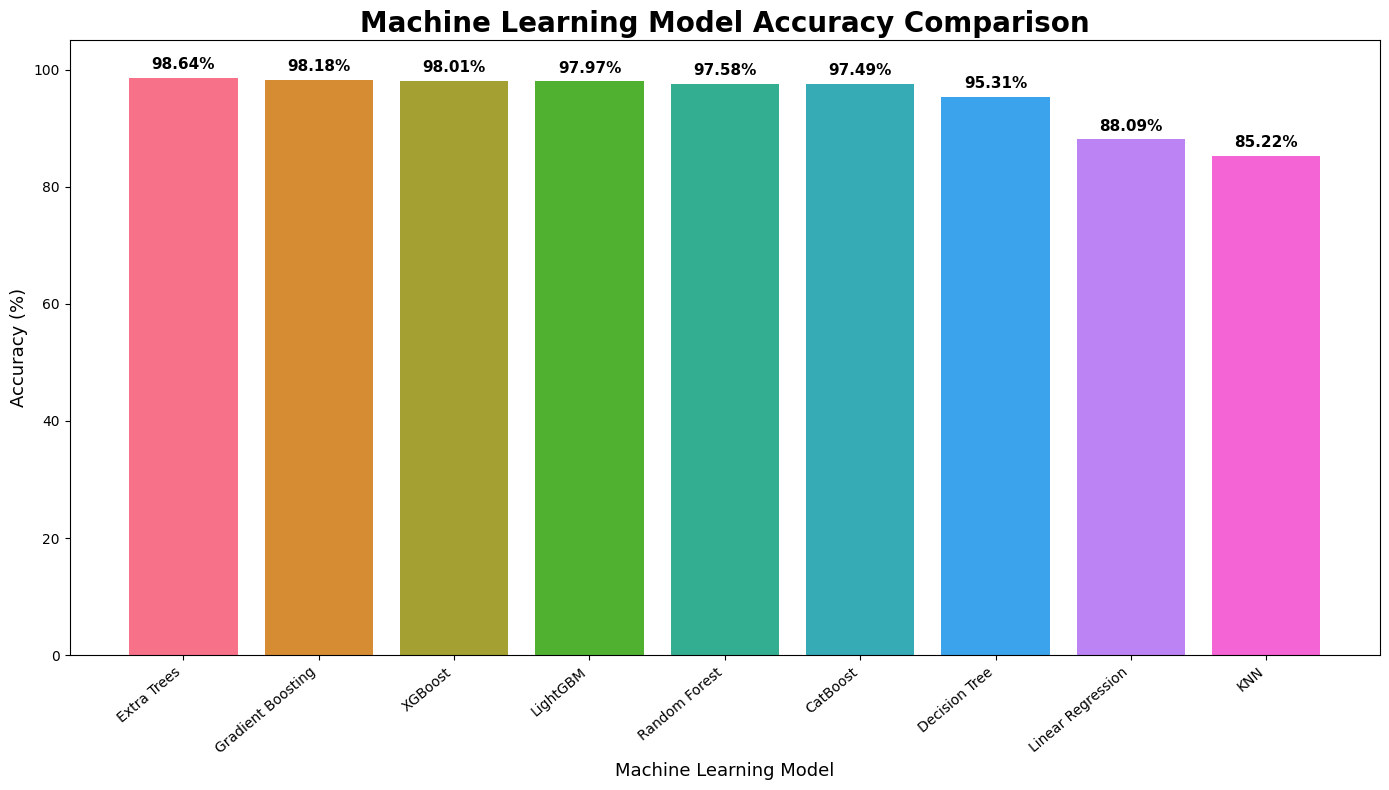

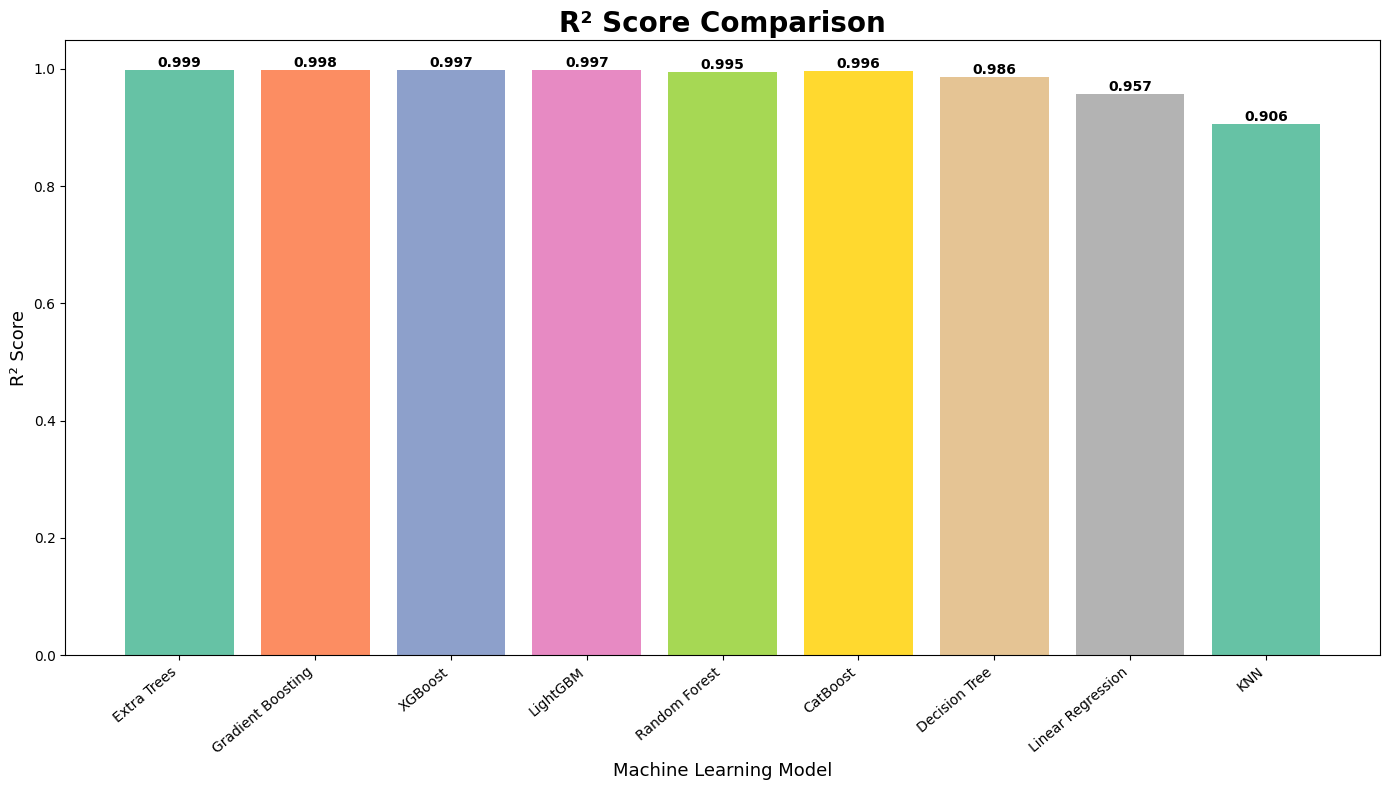

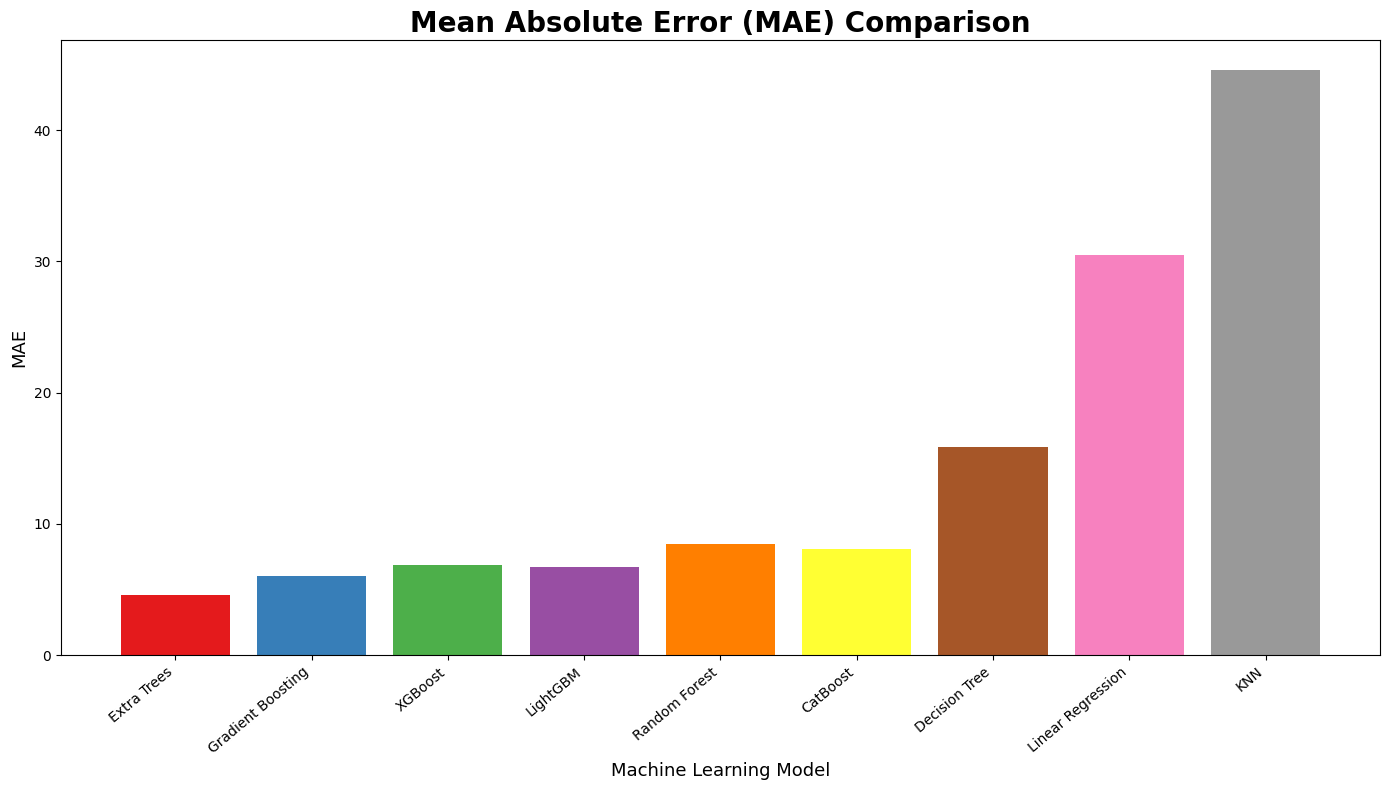

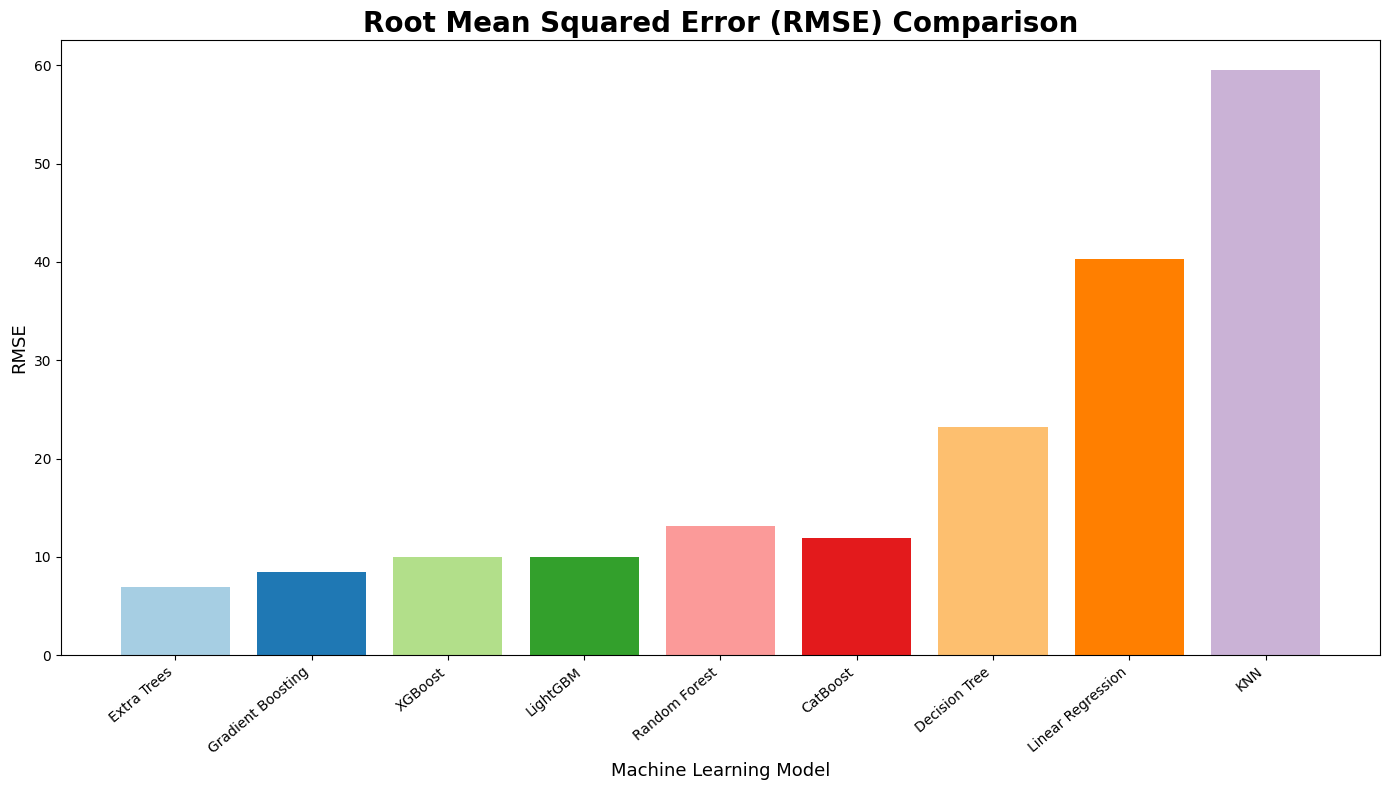

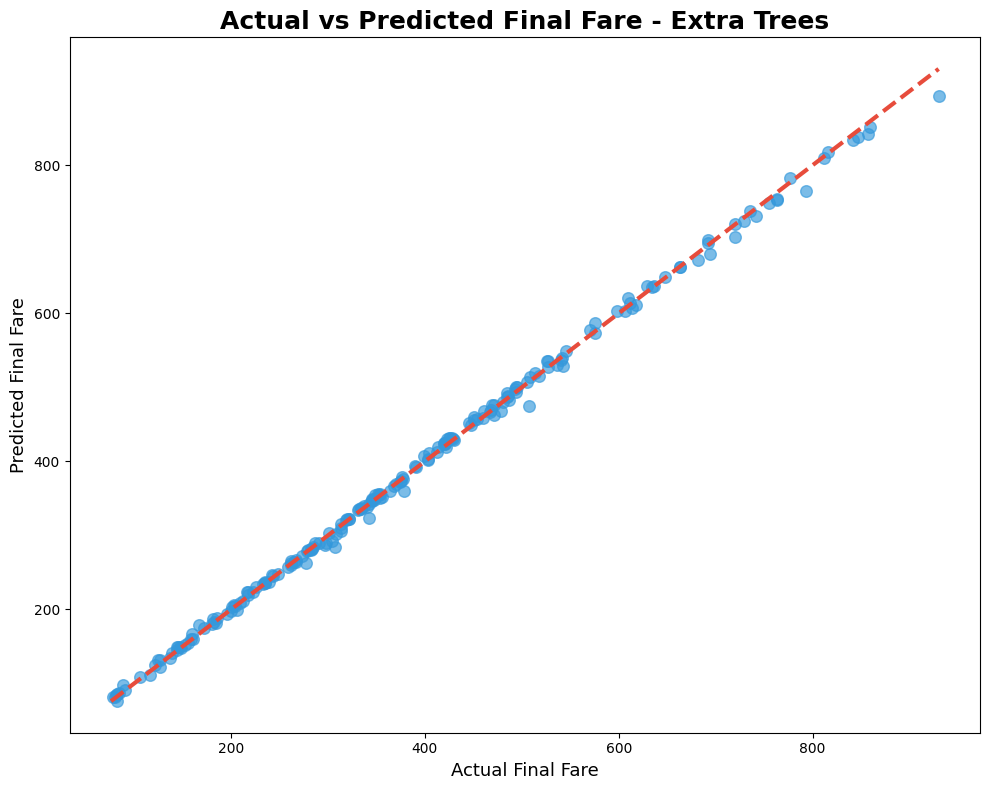

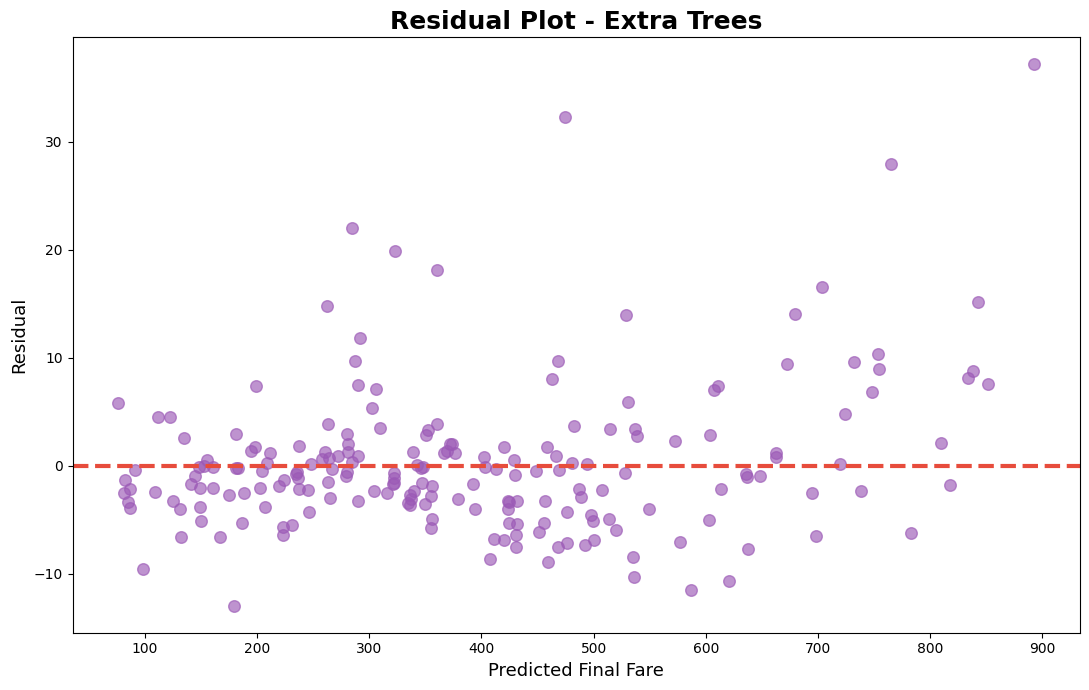


FEATURE IMPORTANCE - Extra Trees


,Feature,Importance
10,Base_Fare,0.333351
3,Distance_km,0.307423
11,Surge_Multiplier,0.223407
9,Trip_Duration,0.113803
8,Demand_Supply_Ratio,0.009108
7,Ride_Requests,0.005989
5,Type_of_vehicle,0.002629
6,No_of_active_drivers,0.001191
1,Hour_of_Day,0.000576
4,Traffic_Level,0.000553


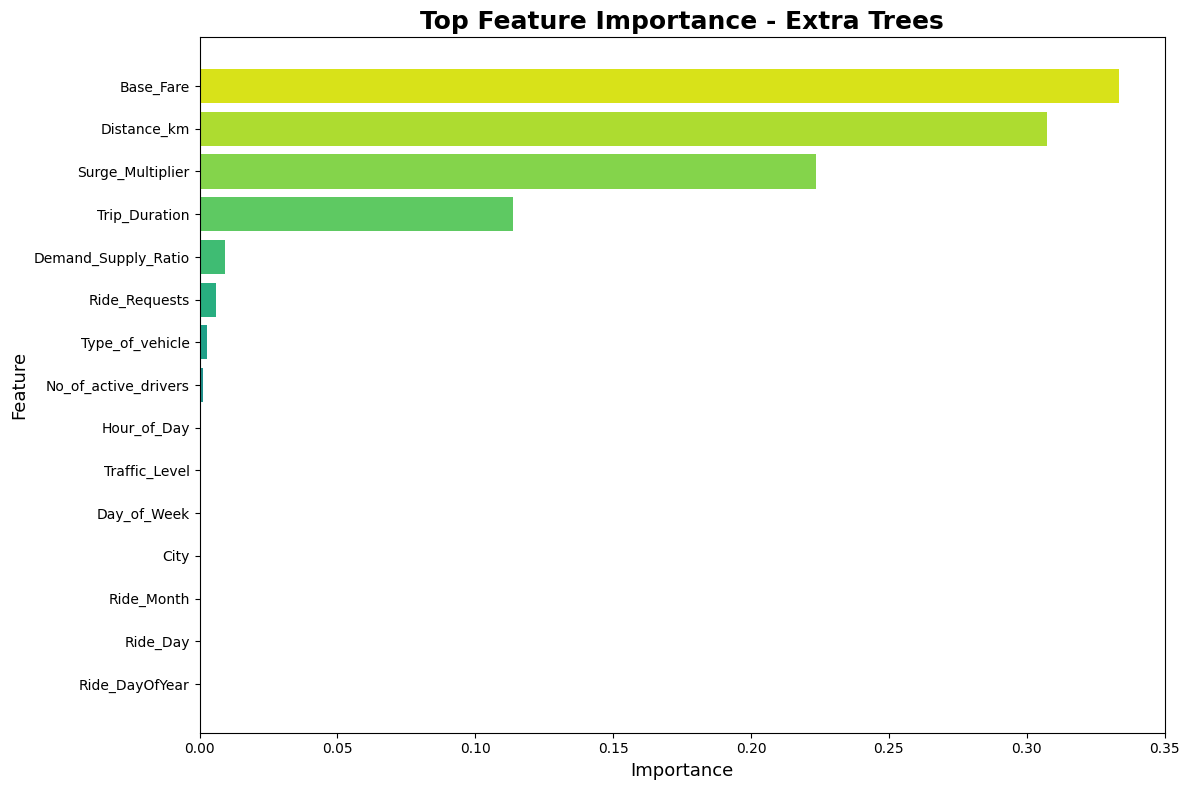


SAMPLE PREDICTIONS


,Actual_Final_Fare,Predicted_Final_Fare,Absolute_Error,Error_Percentage
0,421.04,424.44040,3.40040,0.807619
1,137.18,134.65785,2.52215,1.838570
2,525.77,536.10335,10.33335,1.965375
3,377.84,376.63100,1.20900,0.319977
4,222.67,224.02625,1.35625,0.609085
5,542.69,528.76680,13.92320,2.565590
6,647.44,648.41315,0.97315,0.150307
7,429.36,430.22740,0.86740,0.202022
8,448.04,448.51200,0.47200,0.105348
9,507.04,474.77765,32.26235,6.362881




FINAL MACHINE LEARNING REPORT

Target Variable:
Final_Fare

Problem Type:
Regression

Train Samples:
800

Test Samples:
200

Number of Features:
16

Number of Models:
9

Best Model:
Extra Trees

Best Model Accuracy: 98.64%
Best Model R² Score: 0.9987
Best Model MAE: 4.57
Best Model RMSE: 6.92

MACHINE LEARNING PROCESS COMPLETED SUCCESSFULLY


In [14]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor
)
from sklearn.neighbors import KNeighborsRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# OPTIONAL ML ALGORITHMS
# ============================================================

# XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost is not installed.")

# LightGBM
try:
    from lightgbm import LGBMRegressor
    lgbm_available = True
except ImportError:
    lgbm_available = False
    print("LightGBM is not installed.")

# CatBoost
try:
    from catboost import CatBoostRegressor
    catboost_available = True
except ImportError:
    catboost_available = False
    print("CatBoost is not installed.")


# ============================================================
# 2. LOAD DATASET
# ============================================================

# Change this filename to your actual dataset filename

#df = pd.read_csv("ride_booking.csv")

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())


# ============================================================
# 3. CHECK TARGET VARIABLE
# ============================================================

target = "Final_Fare"

if target not in df.columns:
    raise ValueError(
        f"Target column '{target}' was not found in the dataset."
    )

print("\nTarget Variable:", target)

print("\nTarget Statistics:")
display(df[target].describe())


# ============================================================
# 4. DATA CLEANING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 5. HANDLE RIDE_DATE
# ============================================================

# Convert Ride_Date into useful numerical features

if "Ride_Date" in df.columns:

    df["Ride_Date"] = pd.to_datetime(
        df["Ride_Date"],
        errors="coerce"
    )

    # Extract useful date information
    df["Ride_Year"] = df["Ride_Date"].dt.year
    df["Ride_Month"] = df["Ride_Date"].dt.month
    df["Ride_Day"] = df["Ride_Date"].dt.day
    df["Ride_DayOfYear"] = df["Ride_Date"].dt.dayofyear

    # Remove original date column
    df = df.drop(columns=["Ride_Date"])

print("\nDate processing completed.")


# ============================================================
# 6. REMOVE ID / HIGH-CARDINALITY COLUMNS
# ============================================================

# User_ID is an identifier and normally does not provide
# meaningful predictive information.

# Driver_Name can also create a high-cardinality feature and
# can cause the model to memorize individual drivers.

columns_to_remove = []

if "User_ID" in df.columns:
    columns_to_remove.append("User_ID")

if "Driver_Name" in df.columns:
    columns_to_remove.append("Driver_Name")

if len(columns_to_remove) > 0:
    df = df.drop(columns=columns_to_remove)

print("\nRemoved columns:")
print(columns_to_remove)


# ============================================================
# 7. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[target])
y = df[target]

print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


# ============================================================
# 8. IDENTIFY CATEGORICAL AND NUMERICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

# IMPORTANT:
# Train-test split is performed BEFORE fitting LabelEncoder
# and other preprocessing operations.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ============================================================
# 10. HANDLE MISSING NUMERICAL VALUES
# ============================================================

if len(numerical_columns) > 0:

    numeric_imputer = SimpleImputer(
        strategy="median"
    )

    X_train[numerical_columns] = numeric_imputer.fit_transform(
        X_train[numerical_columns]
    )

    X_test[numerical_columns] = numeric_imputer.transform(
        X_test[numerical_columns]
    )


# ============================================================
# 11. LABEL ENCODING
# ============================================================

print("\n" + "=" * 80)
print("LABEL ENCODING")
print("=" * 80)

# LabelEncoder is fitted ONLY on training data.
#
# To safely handle categories appearing only in test data,
# unseen categories are assigned -1.

label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    # Convert training values to strings
    train_values = X_train[column].astype(str)

    # Fit encoder only on training data
    le.fit(train_values)

    # Transform training data
    X_train[column] = le.transform(train_values)

    # Transform test data safely
    test_values = X_test[column].astype(str)

    known_values = set(le.classes_)

    X_test[column] = test_values.apply(
        lambda value: (
            le.transform([value])[0]
            if value in known_values
            else -1
        )
    )

    label_encoders[column] = le

    print(f"\nColumn: {column}")
    print("Classes:")
    print(list(le.classes_)[:20])


print("\nLabel encoding completed.")


# ============================================================
# 12. HANDLE ANY REMAINING MISSING VALUES
# ============================================================

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

final_imputer = SimpleImputer(
    strategy="median"
)

X_train = pd.DataFrame(
    final_imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    final_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


# ============================================================
# 13. FEATURE SCALING
# ============================================================

# Scaling is useful for Linear Regression and KNN.
# Tree-based models do not require scaling, but we create
# a scaled version for the algorithms that benefit from it.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 14. CREATE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=12,
        min_samples_split=5
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
        min_samples_split=2
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5,
        weights="distance"
    )
}


# ============================================================
# 15. ADD XGBOOST
# ============================================================

if xgb_available:

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )


# ============================================================
# 16. ADD LIGHTGBM
# ============================================================

if lgbm_available:

    models["LightGBM"] = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )


# ============================================================
# 17. ADD CATBOOST
# ============================================================

if catboost_available:

    models["CatBoost"] = CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )


# ============================================================
# 18. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)


for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    # --------------------------------------------------------
    # Use scaled data for Linear Regression and KNN
    # --------------------------------------------------------

    if model_name in [
        "Linear Regression",
        "KNN"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )


    # --------------------------------------------------------
    # Store trained model
    # --------------------------------------------------------

    trained_models[model_name] = model

    predictions[model_name] = y_pred


    # ========================================================
    # REGRESSION METRICS
    # ========================================================

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )


    # ========================================================
    # PERCENTAGE ACCURACY
    # ========================================================

    # Regression does not have conventional classification
    # accuracy. We use a percentage-style accuracy based on
    # relative absolute error.

    y_test_array = np.array(y_test)

    denominator = np.where(
        np.abs(y_test_array) < 1e-8,
        1e-8,
        np.abs(y_test_array)
    )

    percentage_error = (
        np.abs(y_test_array - y_pred)
        / denominator
    ) * 100

    accuracy_percentage = (
        100 - np.mean(percentage_error)
    )

    # Keep the displayed percentage in a meaningful range
    accuracy_percentage = max(
        0,
        min(100, accuracy_percentage)
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append({

        "Model": model_name,

        "Accuracy (%)": accuracy_percentage,

        "R2 Score": r2,

        "MAE": mae,

        "RMSE": rmse

    })


# ============================================================
# 19. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy (%)": "{:.2f}%",
        "R2 Score": "{:.4f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}"
    })
)


# ============================================================
# 20. BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy (%)"]

best_r2 = results_df.iloc[0]["R2 Score"]

print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Best Model:", best_model_name)

print(
    "Accuracy: {:.2f}%".format(
        best_accuracy
    )
)

print(
    "R² Score: {:.4f}".format(
        best_r2
    )
)


# ============================================================
# 21. ACCURACY COMPARISON VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"],
    color=sns.color_palette(
        "husl",
        len(results_df)
    )
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=13
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=13
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.ylim(
    0,
    105
)

# Add accuracy values on bars

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 22. R2 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["R2 Score"],
    color=sns.color_palette(
        "Set2",
        len(results_df)
    )
)

plt.title(
    "R² Score Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=13
)

plt.ylabel(
    "R² Score",
    fontsize=13
)

plt.xticks(
    rotation=40,
    ha="right"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 23. MAE COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["MAE"],
    color=sns.color_palette(
        "Set1",
        len(results_df)
    )
)

plt.title(
    "Mean Absolute Error (MAE) Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=13
)

plt.ylabel(
    "MAE",
    fontsize=13
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 24. RMSE COMPARISON
# ============================================================

plt.figure(figsize=(14, 8))

bars = plt.bar(
    results_df["Model"],
    results_df["RMSE"],
    color=sns.color_palette(
        "Paired",
        len(results_df)
    )
)

plt.title(
    "Root Mean Squared Error (RMSE) Comparison",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model",
    fontsize=13
)

plt.ylabel(
    "RMSE",
    fontsize=13
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 25. ACTUAL VS PREDICTED - BEST MODEL
# ============================================================

best_predictions = predictions[
    best_model_name
]

plt.figure(figsize=(10, 8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.65,
    s=70,
    color="#3498DB"
)

# Perfect prediction line

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="#E74C3C",
    linewidth=3,
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Final Fare - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Actual Final Fare",
    fontsize=13
)

plt.ylabel(
    "Predicted Final Fare",
    fontsize=13
)

plt.tight_layout()
plt.show()


# ============================================================
# 26. RESIDUAL ANALYSIS - BEST MODEL
# ============================================================

residuals = (
    y_test.values -
    best_predictions
)

plt.figure(figsize=(11, 7))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.65,
    s=70,
    color="#9B59B6"
)

plt.axhline(
    y=0,
    color="#E74C3C",
    linestyle="--",
    linewidth=3
)

plt.title(
    f"Residual Plot - {best_model_name}",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Final Fare",
    fontsize=13
)

plt.ylabel(
    "Residual",
    fontsize=13
)

plt.tight_layout()
plt.show()


# ============================================================
# 27. FEATURE IMPORTANCE
# ============================================================

# Feature importance is available for tree-based algorithms.

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "Extra Trees",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

if best_model_name in tree_models:

    best_model = trained_models[
        best_model_name
    ]

    if hasattr(
        best_model,
        "feature_importances_"
    ):

        importance_df = pd.DataFrame({

            "Feature": X_train.columns,

            "Importance":
                best_model.feature_importances_

        })

        importance_df = importance_df.sort_values(
            by="Importance",
            ascending=False
        )

        print("\n" + "=" * 80)
        print(
            f"FEATURE IMPORTANCE - {best_model_name}"
        )
        print("=" * 80)

        display(importance_df)


        # Plot top features

        top_features = importance_df.head(15)

        plt.figure(figsize=(12, 8))

        plt.barh(
            top_features["Feature"][::-1],
            top_features["Importance"][::-1],
            color=sns.color_palette(
                "viridis",
                len(top_features)
            )
        )

        plt.title(
            f"Top Feature Importance - {best_model_name}",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel(
            "Importance",
            fontsize=13
        )

        plt.ylabel(
            "Feature",
            fontsize=13
        )

        plt.tight_layout()
        plt.show()


# ============================================================
# 28. PREDICTION SAMPLE
# ============================================================

prediction_output = pd.DataFrame({

    "Actual_Final_Fare":
        y_test.values,

    "Predicted_Final_Fare":
        best_predictions

})

prediction_output["Absolute_Error"] = (
    np.abs(
        prediction_output["Actual_Final_Fare"]
        -
        prediction_output["Predicted_Final_Fare"]
    )
)

prediction_output["Error_Percentage"] = (
    prediction_output["Absolute_Error"]
    /
    np.maximum(
        np.abs(
            prediction_output["Actual_Final_Fare"]
        ),
        1e-8
    )
) * 100


print("\n" + "=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)

display(
    prediction_output.head(20)
)


# ============================================================
# 29. FINAL MODEL REPORT
# ============================================================

print("\n")
print("=" * 80)
print("FINAL MACHINE LEARNING REPORT")
print("=" * 80)

print("\nTarget Variable:")
print("Final_Fare")

print("\nProblem Type:")
print("Regression")

print("\nTrain Samples:")
print(len(X_train))

print("\nTest Samples:")
print(len(X_test))

print("\nNumber of Features:")
print(X_train.shape[1])

print("\nNumber of Models:")
print(len(models))

print("\nBest Model:")
print(best_model_name)

print(
    "\nBest Model Accuracy: {:.2f}%".format(
        best_accuracy
    )
)

print(
    "Best Model R² Score: {:.4f}".format(
        best_r2
    )
)

best_row = results_df.iloc[0]

print(
    "Best Model MAE: {:.2f}".format(
        best_row["MAE"]
    )
)

print(
    "Best Model RMSE: {:.2f}".format(
        best_row["RMSE"]
    )
)

print("\n" + "=" * 80)
print("MACHINE LEARNING PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

## Thank you...pls upvote!!!!!!!!!!!!